# **Simulador: Ascenso de Colina**
### Capítulo 4 — *Aprendizaje y Comportamiento Adaptable: Principios y Modelos*
**Arturo Bouzas** · Facultad de Psicología, UNAM · bouzaslab25.com

---

Una bacteria (*Salmonella*) busca nutrientes en un entorno con múltiples fuentes de concentración
química. Sin receptores de distancia, solo puede comparar la concentración *ahora* con la
concentración *hace un momento*. La ecuación que gobierna su comportamiento:

$$Y(t+1) = a \cdot Y(t) + b \cdot [X(t+1) - X(t)]$$

| Símbolo | Significado |
|---------|-------------|
| $Y(t)$ | Variable de decisión: positiva → explotar, negativa → explorar |
| $X(t)$ | Concentración química en la posición actual |
| $a$ | Adaptación sensorial $(0 < a < 1)$ |
| $b$ | Sensibilidad al cambio $(b > 0)$ |

**Regla de respuesta:**  $\;Y > 0 \Rightarrow$ **Explotar** (nado recto) $\quad$ $Y \leq 0 \Rightarrow$ **Explorar** (maromas aleatorias)


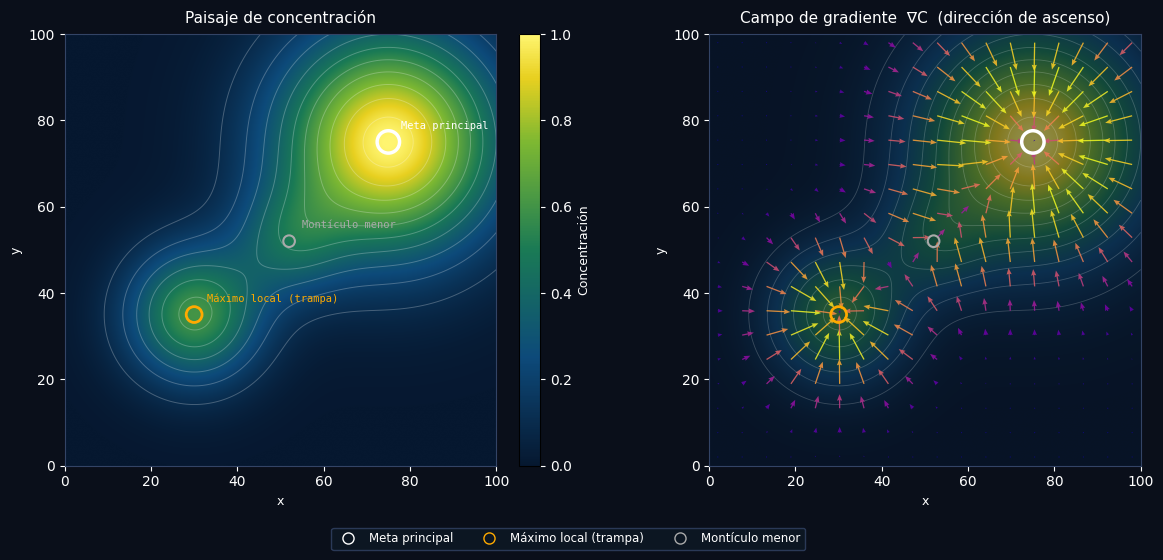

───────────────────────────────────────────────────────
  VERIFICACIÓN DEL PAISAJE
───────────────────────────────────────────────────────
  C(meta)         = 1.0000   ← debería ser el más alto
  C(trampa)       = 0.6055   ← segundo más alto
  C(origen 10,10)   = 0.0088   ← el más bajo
───────────────────────────────────────────────────────


In [ ]:
#@title **Paisaje de Concentración**
#@markdown **Fuentes de nutrientes:** una principal (la meta) y un máximo local (la trampa).

# ═══════════════════════════════════════════════════════════════════════════════
# CELDA 1 — Entorno: Paisaje de concentración (química, glucosa, luz, altura, etc.)
# Paradigma ascenso de colina
# ═══════════════════════════════════════════════════════════════════════════════

# DISEÑO DEL PAISAJE
# ──────────────────
# Se generan tres picos gaussianos superpuestos sobre un gradiente de fondo:
#   Pico principal (meta)   → esquina superior-derecha  | intensidad alta
#   Máximo local (trampa)   → región central-inferior   | intensidad media
#   Montículo menor         → región intermedia         | intensidad baja

# COORDENADAS: el espacio se maneja en [0, 1] × [0, 1] internamente.
# La visualización escala a [0, 100] × [0, 100] para intuición pedagógica.

# FUNCIONES EXPORTADAS (necesarias para celdas posteriores del simulador):
#   get_concentration(x, y)  → valor escalar en (x, y) ∈ [0,1]²
#   get_gradient(x, y)       → vector (dC/dx, dC/dy) — lo que "siente" el agente
# ═══════════════════════════════════════════════════════════════════════════════

# ----- LIBRERIAS -----
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from types import SimpleNamespace
import warnings

warnings.filterwarnings("ignore")

# ── Semilla para reproducibilidad ──────────────────────────────────────────────
np.random.seed(42)
WORLD_SIZE = 2000   # resolución del grid (mayor → gradientes más suaves)

# ══════════════════════════════════════════════════════════════════════════════
# 1. PICOS DEL PAISAJE
# ══════════════════════════════════════════════════════════════════════════════

PEAKS = [
    # ┌─────────────────────────────────────────────────────────────────────┐
    # │  cx, cy  : centro normalizado [0,1]
    # │  strength: altura relativa del pico (Nivel de Concentración)
    # │  sigma   : dispersión (ancho del pico)
    # └─────────────────────────────────────────────────────────────────────┘
    dict(cx=0.75, cy=0.75, strength= 1, sigma=0.18,
         label = "Meta principal",  marker_kw=dict(s=260, lw=2.5)),

    dict(cx=0.3, cy=0.35, strength=0.6, sigma=0.11,
         label = "Máximo local (trampa)",  marker_kw=dict(s=130, lw=2.0)),

    dict(cx=0.52, cy=0.52, strength=0.28, sigma=0.09,
         label="Montículo menor",  marker_kw=dict(s=70, lw=1.5)),
]

# Gradiente de fondo: empuja suavemente hacia arriba-derecha
# Evita zonas de concentración cero (más realista biológicamente)
BG_GRAD = dict(dx=0.001, dy=0.001) # Mínimo

# ══════════════════════════════════════════════════════════════════════════════
# 2. CONSTRUCCIÓN DEL PAISAJE
# ══════════════════════════════════════════════════════════════════════════════

def build_landscape(world_size: int = WORLD_SIZE) -> np.ndarray:
    """
    Retorna grid (world_size × world_size) con valores de concentración
    normalizados en [0, 1].  Origen (0,0) en esquina inferior-izquierda.
    """
    xs = np.linspace(0, 1, world_size)
    ys = np.linspace(0, 1, world_size)
    X, Y = np.meshgrid(xs, ys)

    Z = np.zeros((world_size, world_size))

    # Suma de gaussianas
    for p in PEAKS:
        dx = X - p["cx"]
        dy = Y - p["cy"]
        Z += p["strength"] * np.exp(-(dx**2 + dy**2) / (2 * p["sigma"]**2))


    # Gradiente de fondo suave
    Z += BG_GRAD["dx"] * X + BG_GRAD["dy"] * Y

    # Normalización a [0, 1]
    Z = (Z - Z.min()) / (Z.max() - Z.min())
    return Z


LANDSCAPE = build_landscape()

# ══════════════════════════════════════════════════════════════════════════════
# 3. FUNCIONES DE CONSULTA  (interfaz para el simulador)
# ══════════════════════════════════════════════════════════════════════════════

def get_concentration(x: float, y: float) -> float:
    """
    Concentración en el punto (x, y) con coordenadas normalizadas [0, 1].

    Parámetros
    ----------
    x, y : float — posición en [0, 1]

    Retorna
    -------
    float — concentración ∈ [0, 1]
    """
    x = np.clip(x, 0.0, 1.0)
    y = np.clip(y, 0.0, 1.0)

    # Coordenadas de grilla
    i = y * (WORLD_SIZE - 1)   # fila  (eje y → filas)
    j = x * (WORLD_SIZE - 1)   # col   (eje x → columnas)

    i0, j0 = int(i), int(j)
    i1 = min(i0 + 1, WORLD_SIZE - 1)
    j1 = min(j0 + 1, WORLD_SIZE - 1)

    di, dj = i - i0, j - j0   # fracciones para interpolación

    # Interpolación bilineal
    c = (LANDSCAPE[i0, j0] * (1 - di) * (1 - dj)
       + LANDSCAPE[i1, j0] *      di  * (1 - dj)
       + LANDSCAPE[i0, j1] * (1 - di) *      dj
       + LANDSCAPE[i1, j1] *      di  *      dj)
    return float(c)


def get_gradient(x: float, y: float, eps: float = 0.005) -> tuple[float, float]:
    """
    Gradiente ∇C(x, y) estimado por diferencias finitas centradas.
    Representa el "campo químico sentible" por el agente.

    Parámetros
    ----------
    x, y : float — posición en [0, 1]
    eps  : float — paso de diferencia (default 0.005)

    Retorna
    -------
    (dC/dx, dC/dy) : tuple[float, float]
    """
    dCdx = (get_concentration(x + eps, y) - get_concentration(x - eps, y)) / (2 * eps)
    dCdy = (get_concentration(x, y + eps) - get_concentration(x, y - eps)) / (2 * eps)
    return dCdx, dCdy


# ══════════════════════════════════════════════════════════════════════════════
# 4. VISUALIZACIÓN
# ══════════════════════════════════════════════════════════════════════════════

CMAP = LinearSegmentedColormap.from_list(
    "nutrientes",
    [
        (0.00, "#061830"),   # azul muy oscuro  → concentración mínima
        (0.25, "#0d4a7a"),   # azul medio
        (0.50, "#1a7a55"),   # verde oscuro
        (0.75, "#7db832"),   # verde-amarillo
        (0.90, "#e8d020"),   # amarillo
        (1.00, "#fff570"),   # casi blanco-amarillo → concentración máxima
    ]
)

def plot_landscape(show_gradient: bool = True,
                   gradient_density: int = 16,
                   show_contours: bool = True):
    """
    Visualiza el paisaje de concentración con:
      - Mapa de calor (concentración)
      - Líneas de nivel / isolíneas (topología)
      - Campo vectorial ∇C (lo que "siente" el agente en cada punto)
      - Marcadores de picos

    Parámetros
    ----------
    show_gradient    : mostrar campo vectorial del gradiente
    gradient_density : puntos por eje para el campo de flechas
    show_contours    : mostrar líneas de nivel
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                             gridspec_kw={"width_ratios": [1, 1]})
    fig.patch.set_facecolor("#0a0f1a")

    # ── Panel izquierdo: concentración + contornos ───────────────────────────
    ax = axes[0]
    ax.set_facecolor("#0a0f1a")

    im = ax.imshow(LANDSCAPE, origin="lower", cmap=CMAP,
                   extent=[0, 100, 0, 100], aspect="equal", vmin=0, vmax=1)

    if show_contours:
        levels = np.linspace(0.1, 0.95, 10)
        cs = ax.contour(np.linspace(0, 100, WORLD_SIZE),
                        np.linspace(0, 100, WORLD_SIZE),
                        LANDSCAPE, levels=levels,
                        colors="white", alpha=0.25, linewidths=0.7)

    # Marcadores de picos
    colors_marker = ["#ffffff", "#ffaa00", "#aaaaaa"]
    for p, col in zip(PEAKS, colors_marker):
        cx_px = p["cx"] * 100
        cy_px = p["cy"] * 100
        ax.scatter(cx_px, cy_px,
                   facecolors="none", edgecolors=col,
                   zorder=6, **p["marker_kw"])
        ax.annotate(p["label"],
                    xy=(cx_px, cy_px),
                    xytext=(cx_px + 3, cy_px + 3),
                    color=col, fontsize=7.5,
                    fontfamily="monospace")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Concentración", color="white", fontsize=9)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="white")

    ax.set_title("Paisaje de concentración", color="white", fontsize=11, pad=8)
    ax.set_xlabel("x", color="white", fontsize=9)
    ax.set_ylabel("y", color="white", fontsize=9)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#334466")

    # ── Panel derecho: campo de gradiente ∇C ────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor("#0a0f1a")

    # Fondo suavizado (downsampled para el panel del gradiente)
    ax2.imshow(LANDSCAPE, origin="lower", cmap=CMAP,
               extent=[0, 100, 0, 100], aspect="equal",
               vmin=0, vmax=1, alpha=0.55)

    if show_gradient:
        gx = np.linspace(0.02, 0.98, gradient_density)
        gy = np.linspace(0.02, 0.98, gradient_density)
        GX, GY = np.meshgrid(gx, gy)

        U = np.zeros_like(GX)
        V = np.zeros_like(GY)
        for i in range(gradient_density):
            for j in range(gradient_density):
                U[i, j], V[i, j] = get_gradient(GX[i, j], GY[i, j])

        # Magnitud para colorear las flechas
        mag = np.sqrt(U**2 + V**2)
        mag_norm = mag / (mag.max() + 1e-9)

        ax2.quiver(GX * 100, GY * 100, U, V,
                   mag_norm,
                   cmap="plasma",
                   scale=None,
                   scale_units="xy",
                   angles="xy",
                   width=0.003,
                   headwidth=4,
                   headlength=5,
                   alpha=0.85,
                   zorder=5)

    if show_contours:
        ax2.contour(np.linspace(0, 100, WORLD_SIZE),
                    np.linspace(0, 100, WORLD_SIZE),
                    LANDSCAPE, levels=np.linspace(0.1, 0.95, 10),
                    colors="white", alpha=0.20, linewidths=0.6)

    # Marcadores de picos (repetidos)
    for p, col in zip(PEAKS, colors_marker):
        ax2.scatter(p["cx"] * 100, p["cy"] * 100,
                    facecolors="none", edgecolors=col,
                    zorder=7, **p["marker_kw"])

    ax2.set_title("Campo de gradiente  ∇C  (dirección de ascenso)", color="white",
                  fontsize=11, pad=8)
    ax2.set_xlabel("x", color="white", fontsize=9)
    ax2.set_ylabel("y", color="white", fontsize=9)
    ax2.tick_params(colors="white")
    for spine in ax2.spines.values():
        spine.set_edgecolor("#334466")

    # ── Leyenda compartida ───────────────────────────────────────────────────
    legend_elements = [
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor="none", markeredgecolor=col,
               markersize=8, label=p["label"])
        for p, col in zip(PEAKS, colors_marker)
    ]
    fig.legend(handles=legend_elements,
               loc="lower center", ncol=3,
               fontsize=8.5,
               facecolor="#0d1825", edgecolor="#334466",
               labelcolor="white",
               bbox_to_anchor=(0.5, -0.02))

    # ── Nota metodológica ────────────────────────────────────────────────────
    '''
    note = ("Biológicamente: Salmonella mide  ΔC/Δt  (derivada temporal) "
            "mientras se mueve — no el gradiente espacial directamente.\n"
            "Las flechas muestran ∇C; el agente solo accede "
            "a  C(t)  en su posición actual.")
    fig.text(0.5, -0.07, note, ha="center", va="top",
             fontsize=8, color="#99aabb",
             fontstyle="italic",
             wrap=True)
    '''

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig("landscape_preview.png", dpi=140,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 5. VERIFICACIÓN RÁPIDA
# ══════════════════════════════════════════════════════════════════════════════

def _sanity_check():
    """Verifica que las funciones de consulta devuelven valores razonables."""
    c_meta   = get_concentration(0.75, 0.75)
    c_trampa = get_concentration(0.3, 0.35)
    c_origen = get_concentration(0.10, 0.10)
    g_meta   = get_gradient(0.75, 0.75)
    g_trampa = get_gradient(0.3, 0.35)

    print("─" * 55)
    print("  VERIFICACIÓN DEL PAISAJE")
    print("─" * 55)
    print(f"  C(meta)         = {c_meta:.4f}   ← debería ser el más alto")
    print(f"  C(trampa)       = {c_trampa:.4f}   ← segundo más alto")
    print(f"  C(origen 10,10)   = {c_origen:.4f}   ← el más bajo")
    #print(f"  ∇C en meta      = ({g_meta[0]:+.4f}, {g_meta[1]:+.4f})  ← ≈ (0,0)")
    #print(f"  ∇C en trampa    = ({g_trampa[0]:+.4f}, {g_trampa[1]:+.4f})  ← ≈ (0,0)")
    print("─" * 55)
    assert c_meta > c_trampa > c_origen, "¡Jerarquía de picos incorrecta!"
    '''
    print("  ✓ Jerarquía de concentraciones correcta")
    print("  ✓ Funciones de consulta listas para el simulador\n")
    '''


# ── Ejecución ──────────────────────────────────────────────────────────────────
plot_landscape(show_gradient=True, gradient_density=18, show_contours=True)
_sanity_check()



landscape_original = SimpleNamespace(
    get_concentration = get_concentration,
    get_gradient      = get_gradient,
    grid              = LANDSCAPE,
    peaks             = PEAKS,
    cmap              = CMAP,
)

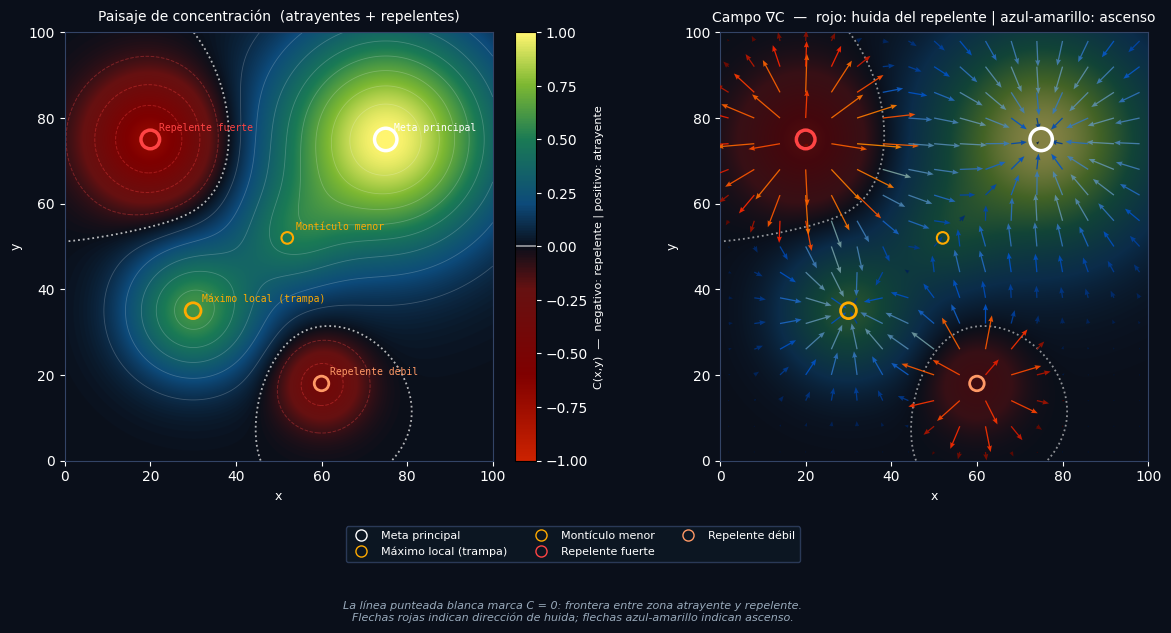

────────────────────────────────────────────────────────────
  VERIFICACIÓN DEL PAISAJE CON REPELENTES
────────────────────────────────────────────────────────────
  [ATRAYENTE]  Meta principal
    centro  = (0.75, 0.75)
    C       = +1.0000   ← > 0 ✓
  [ATRAYENTE]  Máximo local (trampa)
    centro  = (0.30, 0.35)
    C       = +0.6054   ← > 0 ✓
  [ATRAYENTE]  Montículo menor
    centro  = (0.52, 0.52)
    C       = +0.4998   ← > 0 ✓
  [REPELENTE]  Repelente fuerte
    centro  = (0.20, 0.75)
    C       = -0.6878   ← > 0 ✓
  [REPELENTE]  Repelente débil
    centro  = (0.60, 0.18)
    C       = -0.3892   ← > 0 ✓

  [Origen (10, 10)]
    C = +0.0089
────────────────────────────────────────────────────────────
  ✓ Meta con C > 0
  ✓ Ambos repelentes con C < 0
  ✓ Jerarquía de repelentes correcta


In [ ]:
#@title **Paisaje de concentración con repelentes**

# ═══════════════════════════════════════════════════════════════════════════════
# CELDA 2 — Entorno: Paisaje con atrayentes Y repelentes
# Modelo de quimiotaxis tipo Salmonella | Paradigma ascenso de colina
# ═══════════════════════════════════════════════════════════════════════════════

# EXTENSIÓN DEL MODELO
# ────────────────────
# En quimiotaxis real, la Salmonella no solo asciende gradientes de atrayentes
# (nutrientes) sino que también desciende gradientes de repelentes (toxinas,
# ácidos, calor excesivo). Ambos se integran en el mismo campo escalar C(x,y):

#   Atrayente → strength > 0  → gaussiana positiva  → el agente se acerca
#   Repelente → strength < 0  → gaussiana negativa  → el agente huye

# El campo resultante puede tener zonas de C < 0 (dominio repelente puro).
# La normalización ancla el máximo atrayente a +1 y permite valores negativos.

# DIFERENCIA CLAVE CON CELDA 1
# ─────────────────────────────
# • PEAKS incluye entradas con strength < 0
# • El colormap cubre [-1, 1]: rojo → repelente, azul/verde/amarillo → atrayente
# • El campo de gradiente usa colormap rojo en zonas repelentes
# • El sanity_check verifica que el repelente tiene C < 0 en su centro
# ═══════════════════════════════════════════════════════════════════════════════

# LIBRERIAS (Ya cargadas en la celda uno)
# TwoSlopeNorm NO ESTA CARGADA en el módulo 1
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
'''
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")
'''

np.random.seed(42)
WORLD_SIZE = 2000

# ══════════════════════════════════════════════════════════════════════════════
# 1. DEFINICIÓN DE PICOS  (atrayentes y repelentes)
# ══════════════════════════════════════════════════════════════════════════════

#  strength > 0  →  atrayente
#  strength < 0  →  repelente

PEAKS_R = [
    dict(cx=0.75, cy=0.75, strength= 1.00, sigma=0.18,
         label="Meta principal",   marker_kw=dict(s=260, lw=2.5)),

    dict(cx=0.3, cy=0.35, strength= 0.60, sigma=0.11,
         label="Máximo local (trampa)",         marker_kw=dict(s=130, lw=2.0)),

    dict(cx=0.52, cy=0.52, strength= 0.28, sigma=0.09,
         label="Montículo menor",               marker_kw=dict(s=70,  lw=1.5)),

    # ── Repelentes ──────────────────────────────────────────────────────────
    dict(cx=0.20, cy=0.75, strength=-0.70, sigma=0.10,
         label="Repelente fuerte",              marker_kw=dict(s=180, lw=2.5)),

    dict(cx=0.60, cy=0.18, strength=-0.40, sigma=0.07,
         label="Repelente débil",               marker_kw=dict(s=110, lw=2.0)),
]

BG_GRAD_R = dict(dx=0.001, dy=0.001)   # gradiente de fondo suave

# ══════════════════════════════════════════════════════════════════════════════
# 2. CONSTRUCCIÓN DEL PAISAJE
# ══════════════════════════════════════════════════════════════════════════════

def build_landscape_R(world_size: int = WORLD_SIZE) -> np.ndarray:
    """
    Grilla (world_size × world_size) con valores en [-1, +1].
    +1 = máximo atrayente (meta principal)
    -1 = máximo repelente
     0 = zona neutra
    """
    xs = np.linspace(0, 1, world_size)
    ys = np.linspace(0, 1, world_size)
    X, Y = np.meshgrid(xs, ys)

    Z = np.zeros((world_size, world_size))
    for p in PEAKS_R:
        dx = X - p["cx"]
        dy = Y - p["cy"]
        Z += p["strength"] * np.exp(-(dx**2 + dy**2) / (2 * p["sigma"]**2))

    Z += BG_GRAD_R["dx"] * X + BG_GRAD_R["dy"] * Y

    # Anclar el máximo atrayente a +1 usando el valor analítico exacto
    x0, y0 = PEAKS_R[0]["cx"], PEAKS_R[0]["cy"]
    z_peak = sum(
        p["strength"] * np.exp(-((x0 - p["cx"])**2 + (y0 - p["cy"])**2)
                                / (2 * p["sigma"]**2))
        for p in PEAKS_R
    )
    z_peak += BG_GRAD_R["dx"] * x0 + BG_GRAD_R["dy"] * y0
    Z = Z / z_peak

    # Acotar el dominio repelente simétricamente
    Z = np.clip(Z, -1.0, 1.0)
    return Z


LANDSCAPE_R = build_landscape_R()

# ══════════════════════════════════════════════════════════════════════════════
# 3. FUNCIONES DE CONSULTA
# ══════════════════════════════════════════════════════════════════════════════

def get_concentration_R(x: float, y: float) -> float:
    """
    Concentración en (x, y) ∈ [0,1]².
    Valores positivos: zona atrayente.
    Valores negativos: zona repelente.
    """
    x = np.clip(x, 0.0, 1.0)
    y = np.clip(y, 0.0, 1.0)
    i = y * (WORLD_SIZE - 1)
    j = x * (WORLD_SIZE - 1)
    i0, j0 = int(i), int(j)
    i1 = min(i0 + 1, WORLD_SIZE - 1)
    j1 = min(j0 + 1, WORLD_SIZE - 1)
    di, dj = i - i0, j - j0
    c = (LANDSCAPE_R[i0, j0] * (1 - di) * (1 - dj)
       + LANDSCAPE_R[i1, j0] *      di  * (1 - dj)
       + LANDSCAPE_R[i0, j1] * (1 - di) *      dj
       + LANDSCAPE_R[i1, j1] *      di  *      dj)
    return float(c)


def get_gradient_R(x: float, y: float, eps: float = 0.005) -> tuple[float, float]:
    """
    ∇C(x, y) por diferencias finitas centradas.
    En zonas repelentes el vector apunta HACIA AFUERA del repelente,
    indicando la dirección de huida.
    """
    dCdx = (get_concentration_R(x + eps, y) - get_concentration_R(x - eps, y)) / (2 * eps)
    dCdy = (get_concentration_R(x, y + eps) - get_concentration_R(x, y - eps)) / (2 * eps)
    return dCdx, dCdy

# ══════════════════════════════════════════════════════════════════════════════
# 4. COLORMAPS
# ══════════════════════════════════════════════════════════════════════════════

# Mapa divergente: rojo (repelente) → negro (neutro) → amarillo (atrayente)
CMAP = LinearSegmentedColormap.from_list(
    "quimio_divergente",
    [
        (0.00, "#cc2200"),   # rojo vivo       → repelente máximo  (-1)
        (0.20, "#7f0000"),   # rojo oscuro
        (0.40, "#661111"),   # rojo apagado
        (0.50, "#0a0f1a"),   # casi negro        → zona neutra        (0)
        (0.60, "#0d4a7a"),   # azul
        (0.75, "#1a7a55"),   # verde
        (0.88, "#7db832"),   # verde-amarillo
        (1.00, "#fff570"),   # amarillo brillante → atrayente máximo (+1)
    ]
)

# Norma divergente centrada en 0
NORM = TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

# Colormap para flechas del gradiente:
#   rojo   → gradiente alto en zona repelente  (huir)
#   plasma → gradiente alto en zona atrayente  (ascender)
CMAP_GRAD_REP = LinearSegmentedColormap.from_list(
    "grad_repelente", ["#330000", "#ff2200", "#ff8800"]
)
CMAP_GRAD_ATR = LinearSegmentedColormap.from_list(
    "grad_atrayente", ["#001133", "#0055cc", "#fff570"]
)

# ══════════════════════════════════════════════════════════════════════════════
# 5. COLORES DE MARCADORES  (atrayentes blanco/naranja, repelentes rojos)
# ══════════════════════════════════════════════════════════════════════════════

def _marker_color(p: dict) -> str:
    if p["strength"] > 0:
        return "#ffffff" if p["strength"] >= 1.0 else "#ffaa00"
    else:
        return "#ff4444" if p["strength"] <= -0.6 else "#ff9966"

# ══════════════════════════════════════════════════════════════════════════════
# 6. VISUALIZACIÓN
# ══════════════════════════════════════════════════════════════════════════════

def plot_landscape_R(show_gradient: bool = True,
                   gradient_density: int = 18,
                   show_contours: bool = True):

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                             gridspec_kw={"width_ratios": [1, 1]})
    fig.patch.set_facecolor("#0a0f1a")

    xs_plot = np.linspace(0, 100, WORLD_SIZE)
    ys_plot = np.linspace(0, 100, WORLD_SIZE)

    # ── Panel izquierdo: mapa de concentración ───────────────────────────────
    ax = axes[0]
    ax.set_facecolor("#0a0f1a")

    im = ax.imshow(LANDSCAPE_R, origin="lower", cmap=CMAP, norm=NORM,
                   extent=[0, 100, 0, 100], aspect="equal")

    if show_contours:
        # Contornos negativos (repelente) en rojo, positivos en blanco
        ax.contour(xs_plot, ys_plot, LANDSCAPE_R,
                   levels=np.linspace(-0.9, -0.1, 5),
                   colors="#ff4444", alpha=0.35, linewidths=0.7, linestyles="dashed")
        ax.contour(xs_plot, ys_plot, LANDSCAPE_R,
                   levels=np.linspace(0.1, 0.9, 8),
                   colors="white", alpha=0.20, linewidths=0.6)
        # Isolínea C = 0 (frontera atrayente/repelente) destacada
        ax.contour(xs_plot, ys_plot, LANDSCAPE_R,
                   levels=[0.0],
                   colors="#ffffff", alpha=0.70, linewidths=1.3, linestyles="dotted")

    for p in PEAKS_R:
        col = _marker_color(p)
        cx_px, cy_px = p["cx"] * 100, p["cy"] * 100
        ax.scatter(cx_px, cy_px, facecolors="none", edgecolors=col,
                   zorder=6, **p["marker_kw"])
        ax.annotate(p["label"], xy=(cx_px, cy_px),
                    xytext=(cx_px + 2, cy_px + 2),
                    color=col, fontsize=7, fontfamily="monospace")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("C(x,y)  —  negativo: repelente | positivo: atrayente",
                   color="white", fontsize=8)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="white")
    cbar.ax.axhline(0, color="white", lw=1.2, alpha=0.6)   # marca el cero

    ax.set_title("Paisaje de concentración  (atrayentes + repelentes)",
                 color="white", fontsize=10, pad=8)
    ax.set_xlabel("x", color="white", fontsize=9)
    ax.set_ylabel("y", color="white", fontsize=9)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#334466")

    # ── Panel derecho: campo de gradiente ∇C ────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor("#0a0f1a")

    ax2.imshow(LANDSCAPE_R, origin="lower", cmap=CMAP, norm=NORM,
               extent=[0, 100, 0, 100], aspect="equal", alpha=0.50)

    if show_gradient:
        gx = np.linspace(0.02, 0.98, gradient_density)
        gy = np.linspace(0.02, 0.98, gradient_density)
        GX, GY = np.meshgrid(gx, gy)

        U = np.zeros_like(GX)
        V = np.zeros_like(GY)
        C_vals = np.zeros_like(GX)   # concentración en cada punto de la grilla

        for i in range(gradient_density):
            for j in range(gradient_density):
                U[i, j], V[i, j] = get_gradient_R(GX[i, j], GY[i, j])
                C_vals[i, j] = get_concentration_R(GX[i, j], GY[i, j])

        mag = np.sqrt(U**2 + V**2) + 1e-9

        # Separar flechas según signo de la concentración local
        mask_rep = C_vals < 0    # zona repelente
        mask_atr = ~mask_rep     # zona atrayente o neutra

        mag_norm = mag / mag.max()

        for mask, cmap_arr in [(mask_rep, CMAP_GRAD_REP), (mask_atr, CMAP_GRAD_ATR)]:
            if not mask.any():
                continue
            ax2.quiver(
                GX[mask] * 100, GY[mask] * 100,
                U[mask], V[mask],
                mag_norm[mask],
                cmap=cmap_arr,
                clim=(0, 1),
                scale=None, scale_units="xy", angles="xy",
                width=0.003, headwidth=4, headlength=5,
                alpha=0.90, zorder=5
            )

    if show_contours:
        ax2.contour(xs_plot, ys_plot, LANDSCAPE_R, levels=[0.0],
                    colors="white", alpha=0.55, linewidths=1.3, linestyles="dotted")

    for p in PEAKS_R:
        col = _marker_color(p)
        ax2.scatter(p["cx"] * 100, p["cy"] * 100,
                    facecolors="none", edgecolors=col, zorder=7, **p["marker_kw"])

    ax2.set_title("Campo ∇C  —  rojo: huida del repelente | azul-amarillo: ascenso",
                  color="white", fontsize=10, pad=8)
    ax2.set_xlabel("x", color="white", fontsize=9)
    ax2.set_ylabel("y", color="white", fontsize=9)
    ax2.tick_params(colors="white")
    for spine in ax2.spines.values():
        spine.set_edgecolor("#334466")

    # ── Leyenda ──────────────────────────────────────────────────────────────
    legend_elements = [
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor="none", markeredgecolor=_marker_color(p),
               markersize=8, label=p["label"])
        for p in PEAKS_R
    ]
    fig.legend(handles=legend_elements,
               loc="lower center", ncol=3, fontsize=8,
               facecolor="#0d1825", edgecolor="#334466",
               labelcolor="white", bbox_to_anchor=(0.5, -0.04))

    note = ("La línea punteada blanca marca C = 0: frontera entre zona atrayente y repelente.\n"
            "Flechas rojas indican dirección de huida; flechas azul-amarillo indican ascenso.")
    fig.text(0.5, -0.10, note, ha="center", va="top",
             fontsize=8, color="#99aabb", fontstyle="italic")

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig("landscape_repelente.png", dpi=140,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 7. VERIFICACIÓN
# ══════════════════════════════════════════════════════════════════════════════

def _sanity_check_R():
    print("─" * 60)
    print("  VERIFICACIÓN DEL PAISAJE CON REPELENTES")
    print("─" * 60)

    for p in PEAKS_R:
        cx, cy = p["cx"], p["cy"]
        c = get_concentration_R(cx, cy)
        g = get_gradient_R(cx, cy)
        tipo = "ATRAYENTE" if p["strength"] > 0 else "REPELENTE"
        print(f"  [{tipo}]  {p['label']}")
        print(f"    centro  = ({cx:.2f}, {cy:.2f})")
        print(f"    C       = {c:+.4f}   ← {'> 0 ✓' if (p['strength']>0) == (c>0) else '¡signo incorrecto!'}")
        # print(f"    ∇C      = ({g[0]:+.4f}, {g[1]:+.4f})  ← ≈ (0,0) en pico")

    c_origen_R = get_concentration_R(0.10, 0.10)
    print(f"\n  [Origen (10, 10)]")
    print(f"    C = {c_origen_R:+.4f}")
    print("─" * 60)

    # Verificaciones
    c_meta_R    = get_concentration_R(PEAKS_R[0]["cx"], PEAKS_R[0]["cy"])
    c_rep1_R    = get_concentration_R(PEAKS_R[3]["cx"], PEAKS_R[3]["cy"])
    c_rep2_R    = get_concentration_R(PEAKS_R[4]["cx"], PEAKS_R[4]["cy"])

    assert c_meta_R  > 0,   "¡Meta debe ser atrayente (C > 0)!"
    assert c_rep1_R  < 0,   "¡Repelente fuerte debe tener C < 0!"
    assert c_rep2_R  < 0,   "¡Repelente débil debe tener C < 0!"
    assert c_rep1_R  < c_rep2_R, "¡Repelente fuerte debe ser más negativo que el débil!"

    print("  ✓ Meta con C > 0")
    print("  ✓ Ambos repelentes con C < 0")
    print("  ✓ Jerarquía de repelentes correcta")
    #print("  ✓ Funciones listas para el simulador\n")

plot_landscape_R(show_gradient=True, gradient_density=17, show_contours=True)
_sanity_check_R()

In [ ]:
#@title **Simulación del Agente — Modelo de Ascenso de Colina**
##@markdown Implementa la ecuación del capítulo exactamente como aparece en el texto.

# ═══════════════════════════════════════════════════════════════════════════════
# CELDA 3 — Agente de quimiotaxis
# Modelo puro: Y(t+1) = a·Y(t) + b·[X(t+1) − X(t)]
# ═══════════════════════════════════════════════════════════════════════════════

# MODELO
# ──────
#   Y(t+1) = a · Y(t)  +  b · ΔX(t)

#   donde  ΔX(t) = X(t+1) − X(t)    gradiente temporal percibido
#          X(t)  = C(x,y) + ε        concentración medida con ruido

#   Y > 0  →  RUN    : el agente avanza en su dirección actual
#   Y ≤ 0  →  TUMBLE : reorientación aleatoria + avance en la nueva dirección

# PARÁMETROS
# ──────────
#   a ∈ (0,1) — adaptación sensorial
#               Controla cuánto peso tiene el pasado en Y.
#               a → 0 : Y responde solo al ΔX instantáneo (sin memoria)
#               a → 1 : Y es casi inercial (tarda en cambiar de modo)
#               Efecto: a alto → runs más largos pero menos sensibles
#                       a bajo → respuesta rápida pero inestable ante ruido

#   b > 0     — sensibilidad al gradiente temporal
#               Amplifica la señal ΔX antes de sumarla a Y.
#               b pequeño : señal débil, Y decae → tumbles frecuentes
#               b grande  : señal fuerte, pero amplifica también el ruido
#               Efecto: b·σ_noise es el ruido efectivo sobre Y

#   σ_noise ≥ 0 — ruido perceptual (desviación estándar)
#               X_medido = C(x,y) + ε,   ε ~ N(0, σ²)
#               σ = 0   : modelo determinista puro
#               σ > 0   : introduce transiciones run/tumble
#               Relación teórica clave: si b·σ >> |b·ΔX_real|
#               el ruido domina la señal → el agente se comporta aleatoriamente

# LÓGICA RUN / TUMBLE
# ───────────────────
#   Cada paso de tiempo es exactamente uno de dos casos:

#   Caso RUN    (Y > 0):
#     → el agente avanza en su dirección actual θ
#     → mide X en la nueva posición
#     → actualiza Y con la ecuación del modelo
#     → si Y cae ≤ 0: el siguiente paso será tumble

#   Caso TUMBLE (Y ≤ 0):
#     → se sortea un nuevo ángulo θ ~ U(0, 2π)
#     → el agente avanza UNA vez en la nueva dirección
#     → mide X en la nueva posición
#     → actualiza Y con la ecuación del modelo
#     → si Y sube > 0: el siguiente paso será run

#   Nota: el tumble siempre incluye un movimiento. Si no hubiera movimiento,
#   ΔX = 0 y Y solo decaería → a·Y ≤ 0 → tumble eterno. El avance post-tumble
#   es lo que permite a Y recuperarse y volver a run.

# ═══════════════════════════════════════════════════════════════════════════════

# import numpy as np #(Ya cargada)

# ══════════════════════════════════════════════════════════════════════════════
# 1. PARÁMETROS POR DEFECTO
# ══════════════════════════════════════════════════════════════════════════════

AGENT_DEFAULTS = dict(
    a           = 0.70,    # adaptación sensorial              (0 < a < 1)
    b           = 8.0,     # sensibilidad al gradiente         (b > 0)
    sigma_noise = 0.00,    # ruido perceptual                  (≥ 0)
    speed       = 0.008,   # velocidad por paso [u. norm.]
    x0          = 0.10,    # posición inicial x
    y0          = 0.10,    # posición inicial y
    Y0          = 0.0,     # estado interno inicial (neutro)
)

# ══════════════════════════════════════════════════════════════════════════════
# 2. CLASE AGENTE
# ══════════════════════════════════════════════════════════════════════════════

class SalmonellaAgent:
    """
    Agente de quimiotaxis con lógica run/tumble derivada del modelo:

        Y(t+1) = a·Y(t) + b·[X(t+1) − X(t)]

    """

    def __init__(self, landscape, params: dict = None):
        """
        Parámetros
        ----------
        landscape : objeto Landscape  — entorno del agente
        params    : dict opcional     — sobreescribe AGENT_DEFAULTS
        """
        self.landscape = landscape
        p = {**AGENT_DEFAULTS, **(params or {})}

        # Parámetros del modelo
        self.a           = p["a"]
        self.b           = p["b"]
        self.sigma_noise = p["sigma_noise"]
        self.speed       = p["speed"]

        # Estado cinemático
        self.x     = p["x0"]
        self.y     = p["y0"]
        self.theta = np.random.uniform(0, 2 * np.pi)

        # Variable de decisión
        self.Y = p["Y0"]

        # Modo inicial derivado del signo de Y
        self.mode = "run" if self.Y > 0 else "tumble"

        # Medición inicial
        self.X_prev = self._measure()

        # Historial
        self.history_x    = [self.x]
        self.history_y    = [self.y]
        self.history_Y    = [self.Y]
        self.history_X    = [self.X_prev]
        self.history_mode = [self.mode]
        self.history_dX   = [0.0]

    # ── Medición con ruido perceptual ──────────────────────────────────────
    def _measure(self) -> float:
        """
        X_medido = C(x, y) + ε,   ε ~ N(0, σ²)
        Con σ = 0 el modelo es determinista.
        """
        c = self.landscape.get_concentration(self.x, self.y)
        if self.sigma_noise > 0:
            c += np.random.normal(0.0, self.sigma_noise)
        return c

    # ── Avance en dirección θ con reflexión en bordes ──────────────────────
    def _advance(self):
        """
        Mueve al agente una unidad de velocidad en la dirección θ actual.
        Reflexión especular en los bordes para mantener el dominio [0,1]².
        """
        new_x = self.x + self.speed * np.cos(self.theta)
        new_y = self.y + self.speed * np.sin(self.theta)

        if new_x < 0.0 or new_x > 1.0:
            self.theta = np.pi - self.theta
            new_x = np.clip(new_x, 0.0, 1.0)
        if new_y < 0.0 or new_y > 1.0:
            self.theta = -self.theta
            new_y = np.clip(new_y, 0.0, 1.0)

        self.x = new_x
        self.y = new_y

    # ── Paso principal ─────────────────────────────────────────────────────
    def step(self):
        """
        Un paso de tiempo.

        Caso RUN    (Y > 0): avanza en dirección actual.
        Caso TUMBLE (Y ≤ 0): sortea nueva dirección y avanza.

        En ambos casos:
          - se mide X en la nueva posición
          - se actualiza Y con la ecuación del modelo
          - el modo del siguiente paso se deriva del signo de Y
        """
        # ── Movimiento ────────────────────────────────────────────────────
        if self.mode == "run":
            self._advance()
        else:
            # Tumble: nueva dirección aleatoria, luego avance
            self.theta = np.random.uniform(0, 2 * np.pi)
            self._advance()

        # ── Percepción ────────────────────────────────────────────────────
        X_new = self._measure()
        dX    = X_new - self.X_prev          # gradiente temporal

        # ── Ecuación del modelo ───────────────────────────────────────────
        #   Y(t+1) = a·Y(t) + b·ΔX(t)
        self.Y = self.a * self.Y + self.b * dX

        # ── Modo siguiente: exclusivamente del signo de Y ─────────────────
        self.mode = "run" if self.Y > 0 else "tumble"

        # ── Actualizar estado y registrar ─────────────────────────────────
        self.X_prev = X_new

        self.history_x.append(self.x)
        self.history_y.append(self.y)
        self.history_Y.append(self.Y)
        self.history_X.append(X_new)
        self.history_mode.append(self.mode)
        self.history_dX.append(dX)

    # ── Simulación de N pasos ──────────────────────────────────────────────
    def run_simulation(self, n_steps: int = 2000):
        for _ in range(n_steps):
            self.step()
        return self

    # ── Diagnóstico ────────────────────────────────────────────────────────
    def summary(self):
        total  = len(self.history_mode)
        n_run  = self.history_mode.count("run")
        n_tumb = self.history_mode.count("tumble")
        c_fin  = self.landscape.get_concentration(self.x, self.y)

        print("─" * 58)
        print("  RESUMEN DEL AGENTE")
        print("─" * 58)
        print(f"  Modelo:  Y(t+1) = a·Y(t) + b·ΔX(t)")
        print(f"  a = {self.a};   b = {self.b};   ruido(σ) = {self.sigma_noise}")
        print(f"  Pasos totales   : {total}")
        print(f"  Pasos en run    : {n_run}  ({100*n_run/total:.1f}%)")
        print(f"  Pasos en tumble : {n_tumb}  ({100*n_tumb/total:.1f}%)")
        print(f"  Posición final  : ({self.x:.3f}, {self.y:.3f})")
        print(f"  C(posición final): {c_fin:.4f}")
        print("─" * 58)


# ══════════════════════════════════════════════════════════════════════════════
# 3. CASOS DE PRUEBA
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(42)

print("Caso 1 — Parámetros balanceados, sin ruido")
ag1 = SalmonellaAgent(landscape_original,
                      dict(a=0.70, b=8.0, sigma_noise=0.00))
ag1.run_simulation(2000)
ag1.summary()

print("\nCaso 2 — Alta inercia  (a → 1)")
ag2 = SalmonellaAgent(landscape_original,
                      dict(a=0.95, b=8.0, sigma_noise=0.00))
ag2.run_simulation(2000)
ag2.summary()

print("\nCaso 3 — Sin inercia  (a → 0)")
ag3 = SalmonellaAgent(landscape_original,
                      dict(a=0.05, b=8.0, sigma_noise=0.00))
ag3.run_simulation(2000)
ag3.summary()

print("\nCaso 4 — Ruido alto  (b·σ domina la señal)")
ag4 = SalmonellaAgent(landscape_original,
                      dict(a=0.70, b=8.0, sigma_noise=0.05))
ag4.run_simulation(2000)
ag4.summary()

print("\nCaso 5 — Sensibilidad baja  (b pequeño)")
ag5 = SalmonellaAgent(landscape_original,
                      dict(a=0.70, b=1.5, sigma_noise=0.00))
ag5.run_simulation(2000)
ag5.summary()

# ══════════════════════════════════════════════════════════════════════════════
# 4. GUÍA DE PARÁMETROS
# ══════════════════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════╗
║       GUÍA DE PARÁMETROS — MODELO Y(t+1) = a·Y(t) + b·ΔX(t)      ║
╠══════════════════════════════════════════════════════════════════╣

  ▸ a  — Inercia sensorial (memoria)          rango: (0.01 – 0.99)
  ───────────────────────────────────────────────────────────────
    Controla cuánto peso tiene el pasado sobre el estado interno Y.
    • a → 0 : Y se renueva casi por completo cada paso.
              Sin memoria. Respuesta puramente instantánea.
              Runs muy cortos. Alta exploración.
    • a → 1 : Y decae muy lento. Alta inercia.
              Runs muy largos. El agente puede sobrepasar picos
              (sigue en run aunque el gradiente ya sea negativo).
    Rango funcional recomendado: 0.5 – 0.95

  ▸ b  — Sensibilidad al gradiente temporal   rango: (0.5 – 30)
  ───────────────────────────────────────────────────────────────
    Amplifica la diferencia ΔX = X(t+1) − X(t) antes de sumarla
    a Y. Actúa como ganancia del detector de gradiente.
    • b pequeño : señal débil → Y decae rápido → más tumbles.
    • b grande  : señal fuerte → Y sube fácil → más runs.
    ⚠ Con ruido: b también amplifica el ruido perceptual.
      El efecto neto es b·σ (ruido efectivo sobre Y).
      Si b·σ >> |ΔX_real| → el ruido domina la decisión.
    Rango funcional recomendado: 5 – 15

  ▸ σ  — Ruido perceptual                     rango: (0.00 – 0.10)
  ───────────────────────────────────────────────────────────────
    Desviación estándar del ruido gaussiano añadido a la medición:
      X_medido = C(x,y) + ε,   ε ~ N(0, σ²)
    • σ = 0   : modelo determinista. Mismos params → misma ruta.
    • σ > 0   : introduce transiciones run/tumble espurias.
    Indicador clave → b·σ:
      b·σ < 0.10  : ruido despreciable
      b·σ ∈ [0.10, 0.30]  : ruido perceptible
      b·σ > 0.30  : ruido domina la señal química

  ▸ DECISIÓN RUN / TUMBLE
  ───────────────────────────────────────────────────────────────
    El umbral es fijo en Y = 0:
      Y(t) > 0  →  RUN    : avanza en dirección actual θ
      Y(t) ≤ 0  →  TUMBLE : reorienta θ ~ U(0, 2π) y avanza

  ▸ RELACIONES ENTRE PARÁMETROS
  ───────────────────────────────────────────────────────────────
    a alto + b alto  → runs muy largos, overshoot de picos
    a bajo + b bajo  → exploración casi aleatoria
    a medio + b medio + σ=0  → ascenso de colina eficiente
    cualquier combo + b·σ > 0.3  → comportamiento errático
══════════════════════════════════════════════════════════════════
""")

Caso 1 — Parámetros balanceados, sin ruido
──────────────────────────────────────────────────────────
  RESUMEN DEL AGENTE
──────────────────────────────────────────────────────────
  Modelo:  Y(t+1) = a·Y(t) + b·ΔX(t)
  a = 0.7;   b = 8.0;   ruido(σ) = 0.0
  Pasos totales   : 2001
  Pasos en run    : 1083  (54.1%)
  Pasos en tumble : 918  (45.9%)
  Posición final  : (0.288, 0.378)
  C(posición final): 0.5845
──────────────────────────────────────────────────────────

Caso 2 — Alta inercia  (a → 1)
──────────────────────────────────────────────────────────
  RESUMEN DEL AGENTE
──────────────────────────────────────────────────────────
  Modelo:  Y(t+1) = a·Y(t) + b·ΔX(t)
  a = 0.95;   b = 8.0;   ruido(σ) = 0.0
  Pasos totales   : 2001
  Pasos en run    : 1138  (56.9%)
  Pasos en tumble : 863  (43.1%)
  Posición final  : (0.777, 0.786)
  C(posición final): 0.9697
──────────────────────────────────────────────────────────

Caso 3 — Sin inercia  (a → 0)
───────────────────────────────────

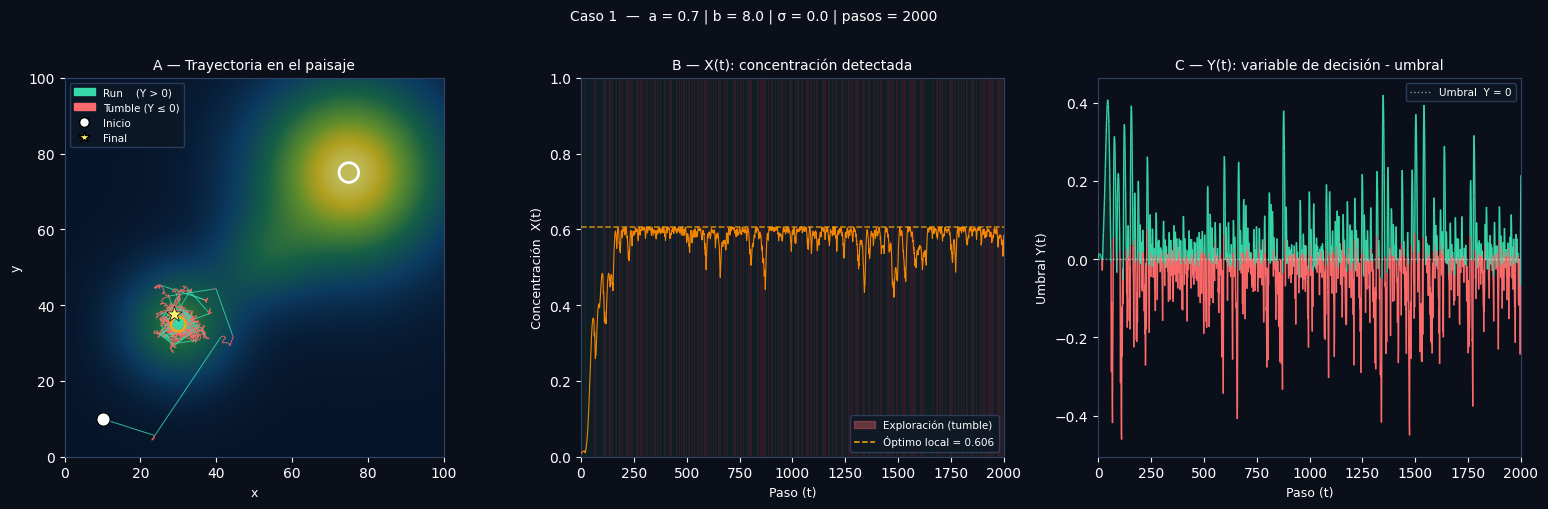

──────────────────────────────────────────────────────────
  RESUMEN DEL AGENTE
──────────────────────────────────────────────────────────
  Modelo:  Y(t+1) = a·Y(t) + b·ΔX(t)
  a = 0.7;   b = 8.0;   ruido(σ) = 0.0
  Pasos totales   : 2001
  Pasos en run    : 1083  (54.1%)
  Pasos en tumble : 918  (45.9%)
  Posición final  : (0.288, 0.378)
  C(posición final): 0.5845
──────────────────────────────────────────────────────────


In [ ]:
#@title **Visualización — Caso 1**

# ═══════════════════════════════════════════════════════════════════════════════
# CELDA 4 — Visualización del caso estándar
# Requiere: Cell 1 (landscape_original) y Cell 3 (SalmonellaAgent)
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# ══════════════════════════════════════════════════════════════════════════════
# 1. SIMULACIÓN
# ══════════════════════════════════════════════════════════════════════════════

N_STEPS = 2000

np.random.seed(42)
agent = SalmonellaAgent(
    landscape_original,
    dict(a=0.70, b=8.0, sigma_noise=0.00, speed=0.008, x0=0.10, y0=0.10)
)
agent.run_simulation(N_STEPS)

# ── Arrays de trabajo ─────────────────────────────────────────────────────────
hx    = np.array(agent.history_x)
hy    = np.array(agent.history_y)
hX    = np.array(agent.history_X)
hY    = np.array(agent.history_Y)
hmode = np.array(agent.history_mode)
steps = np.arange(len(hx))

is_run = hmode == "run"

# Referencias de concentración
c_meta   = landscape_original.get_concentration(PEAKS[0]["cx"], PEAKS[0]["cy"])
c_trampa = landscape_original.get_concentration(PEAKS[1]["cx"], PEAKS[1]["cy"])

# ══════════════════════════════════════════════════════════════════════════════
# 2. ESTILO
# ══════════════════════════════════════════════════════════════════════════════

BG       = "#0a0f1a"
COL_RUN  = "#38d9a9"   # verde-cyan  → run
COL_TUMB = "#ff6b6b"   # rojo suave  → tumble
COL_META = "#fff570"   # amarillo    → meta
COL_TRAP = "#ffaa00"   # naranja     → trampa


def _shade_modes(ax, steps, is_run):
    """Colorea el fondo del eje por bloques de modo run / tumble."""
    in_block = False
    mode_now = None
    t_start  = 0

    for t in range(len(steps)):
        m = "run" if is_run[t] else "tumble"
        if not in_block:
            in_block = True
            mode_now = m
            t_start  = steps[t]
        elif m != mode_now:
            col   = COL_RUN  if mode_now == "run" else COL_TUMB
            alpha = 0.08     if mode_now == "run" else 0.15
            ax.axvspan(t_start, steps[t], color=col, alpha=alpha, lw=0)
            mode_now = m
            t_start  = steps[t]

    col   = COL_RUN  if mode_now == "run" else COL_TUMB
    alpha = 0.08     if mode_now == "run" else 0.15
    ax.axvspan(t_start, steps[-1], color=col, alpha=alpha, lw=0)


def _style_ax(ax):
    """Aplica estilo oscuro uniforme a un eje."""
    ax.set_facecolor(BG)
    ax.tick_params(colors="white")
    for sp in ax.spines.values():
        sp.set_edgecolor("#334466")


# ══════════════════════════════════════════════════════════════════════════════
# 3. FIGURA
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [1.1, 1, 1]}
)
fig.patch.set_facecolor(BG)
fig.suptitle(
    f"Caso 1  —  a = {agent.a} | b = {agent.b} | "
    f"σ = {agent.sigma_noise} | pasos = {N_STEPS}",
    color="white", fontsize=10, y=1.01
)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL A — Trayectoria sobre el paisaje
# ══════════════════════════════════════════════════════════════════════════════

ax_a = axes[0]
_style_ax(ax_a)

# Fondo: paisaje de concentración
ax_a.imshow(
    landscape_original.grid,
    origin="lower", cmap=landscape_original.cmap,
    extent=[0, 100, 0, 100], aspect="equal",
    vmin=0, vmax=1, alpha=0.75
)

# Trayectoria coloreada por modo (LineCollection para eficiencia)
points = np.array([hx * 100, hy * 100]).T.reshape(-1, 1, 2)
segs   = np.concatenate([points[:-1], points[1:]], axis=1)
cols   = [COL_RUN if is_run[i] else COL_TUMB for i in range(len(segs))]
lc = LineCollection(segs, colors=cols, linewidths=0.7, alpha=0.85, zorder=3)
ax_a.add_collection(lc)

# Marcador inicio
ax_a.scatter(
    hx[0] * 100, hy[0] * 100,
    s=90, color="#ffffff", edgecolors="#000000", linewidths=0.8,
    zorder=6, marker="o"
)
# Marcador final
ax_a.scatter(
    hx[-1] * 100, hy[-1] * 100,
    s=140, color=COL_META, edgecolors="#000000", linewidths=0.5,
    zorder=6, marker="*"
)
# Anillos de referencia de picos
ax_a.scatter(PEAKS[0]["cx"] * 100, PEAKS[0]["cy"] * 100,
             s=200, facecolors="none", edgecolors="#ffffff", lw=2, zorder=5)
ax_a.scatter(PEAKS[1]["cx"] * 100, PEAKS[1]["cy"] * 100,
             s=110, facecolors="none", edgecolors=COL_TRAP, lw=1.5, zorder=5)

ax_a.set_title("A — Trayectoria en el paisaje", color="white", fontsize=10, pad=6)
ax_a.set_xlabel("x", color="white", fontsize=9)
ax_a.set_ylabel("y", color="white", fontsize=9)
ax_a.legend(
    handles=[
        mpatches.Patch(color=COL_RUN,  label="Run    (Y > 0)"),
        mpatches.Patch(color=COL_TUMB, label="Tumble (Y ≤ 0)"),
        plt.Line2D([0],[0], marker="o", color="none",
                   markerfacecolor="white", markersize=7, label="Inicio"),
        plt.Line2D([0],[0], marker="*", color="none",
                   markerfacecolor=COL_META, markersize=9, label="Final"),
    ],
    fontsize=7.5, facecolor="#0d1825", edgecolor="#334466",
    labelcolor="white", loc="upper left"
)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL B — X(t): concentración medida
# ══════════════════════════════════════════════════════════════════════════════
mpatches.Patch(color=COL_TUMB, alpha=0.35, label="Exploración (tumble)")

ax_b = axes[1]
_style_ax(ax_b)
_shade_modes(ax_b, steps, is_run)

ax_b.plot(steps, hX, color="#ff8c00", linewidth=0.8, alpha=0.95, zorder=3)

# Techo del eje en 1 (concentración máxima posible)
ax_b.set_ylim(0, 1)

# Referencia: máximo local (trampa) — línea punteada
ax_b.axhline(
    c_trampa,
    color=COL_TRAP, linewidth=1.1, linestyle="--", alpha=0.80, zorder=4,
    label=f"Máximo local (trampa) = {c_trampa:.3f}"
)

ax_b.set_title("B — X(t): concentración detectada", color="white", fontsize=10, pad=6)
ax_b.set_xlabel("Paso (t)", color="white", fontsize=9)
ax_b.set_ylabel("Concentración  X(t)", color="white", fontsize=9)
ax_b.set_xlim(0, len(steps) - 1)
ax_b.legend(
    handles=[
        mpatches.Patch(color=COL_TUMB, alpha=0.35, label="Exploración (tumble)"),
        plt.Line2D([0],[0], color=COL_TRAP, linewidth=1.1,
                   linestyle="--", label=f"Óptimo local = {c_trampa:.3f}"),
    ],
    fontsize=7.5, facecolor="#0d1825",
    edgecolor="#334466", labelcolor="white", loc="lower right"
)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL C — Y(t): variable de decisión
# ══════════════════════════════════════════════════════════════════════════════

ax_c = axes[2]
_style_ax(ax_c)
#_shade_modes(ax_c, steps, is_run)

# Umbral Y = 0
ax_c.axhline(
    0, color="white", linewidth=1.0, linestyle=":", alpha=0.55, zorder=4,
    label="Umbral  Y = 0"
)


# Curva Y(t) coloreada por modo
points_y = np.array([steps, hY]).T.reshape(-1, 1, 2)
segs_y   = np.concatenate([points_y[:-1], points_y[1:]], axis=1)
col_y = [COL_RUN if (hY[i] + hY[i+1]) / 2 > 0 else COL_TUMB
         for i in range(len(segs_y))]
lc_y = LineCollection(segs_y, colors=col_y, linewidths=1.0, alpha=0.95, zorder=3)
ax_c.add_collection(lc_y)

ax_c.fill_between(steps, hY, 0,
                  where=(hY >  0), color=COL_RUN,  alpha=0.12, zorder=2)
ax_c.fill_between(steps, hY, 0,
                  where=(hY <= 0), color=COL_TUMB, alpha=0.18, zorder=2)

ax_c.set_title("C — Y(t): variable de decisión - umbral", color="white", fontsize=10, pad=6)
ax_c.set_xlabel("Paso (t)", color="white", fontsize=9)
ax_c.set_ylabel("Umbral Y(t)", color="white", fontsize=9)
ax_c.set_xlim(0, len(steps) - 1)
ax_c.legend(
    fontsize=7.5, facecolor="#0d1825",
    edgecolor="#334466", labelcolor="white", loc="upper right"
)

# ══════════════════════════════════════════════════════════════════════════════
# 4. CIERRE
# ══════════════════════════════════════════════════════════════════════════════

plt.tight_layout(rect=[0, 0.0, 1, 1])
plt.savefig("simulacion_caso1.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

agent.summary()

In [ ]:
#@title **Módulo Interactivo — Explorador de Parámetros**

# ═══════════════════════════════════════════════════════════════════════════════
# CELDA 5 — Explorador interactivo
# Requiere: landscape_original (Cell 1) y SalmonellaAgent (Cell 3)
#
# PARÁMETROS CONTROLABLES
# ───────────────────────
#   a           — inercia sensorial           (0.01 – 0.99)
#   b           — sensibilidad al gradiente   (0.5  – 30.0)
#   σ           — ruido perceptual            (0.00 – 0.10)
#   pasos       — duración de la simulación   (200  – 5000)
#   x₀, y₀     — posición inicial del agente (0.05 – 0.95)
#
# RESET → restaura todos los controles al preset "Balance óptimo"
# ═══════════════════════════════════════════════════════════════════════════════

import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# ══════════════════════════════════════════════════════════════════════════════
# 1. DEFAULTS Y PRESETS
# ══════════════════════════════════════════════════════════════════════════════

DEFAULTS = dict(
    a      = 0.65,
    b      = 10.0,
    sigma  = 0.00,
    steps  = 2000,
    x0     = 0.10,
    y0     = 0.10,
    seed   = 42,
)

PRESETS = {
    "Balance óptimo": dict(
        a=0.65, b=10.0, sigma=0.00, steps=2000, x0=0.10, y0=0.60, seed=42,
        desc=(
            "Parámetros medios + inicio en zona de ascenso directo al máximo global. "
            "Memoria moderada (a=0.65) y sensibilidad media-alta (b=10) permiten "
            "sostener runs en gradiente positivo y tumbles rápidos al caer la señal. "
            "Resultado: llega al máximo global (C≈0.99) en 2000 pasos."
        )
    ),
    "Atrapado en óptimo local": dict(
        a=0.96, b=5.0, sigma=0.00, steps=2000, x0=0.05, y0=0.05, seed=42,
        desc=(
            "Inercia muy alta (a=0.96): una vez que Y sube cerca del óptimo local, "
            "decae tan lento que el agente sigue en run aunque el gradiente caiga. "
            "Al llegar al pico de la trampa (C≈0.60), Y tarda muchos pasos en volverse "
            "negativo; los tumbles producen Y tan negativo que el agente no puede "
            "escapar hacia el máximo global. Queda oscilando en (0.30, 0.35)."
        )
    ),
    "Exploración excesiva": dict(
        a=0.15, b=2.0, sigma=0.00, steps=2000, x0=0.10, y0=0.10, seed=42,
        desc=(
            "Sin memoria (a=0.15) + señal débil (b=2): Y se renueva casi por "
            "completo cada paso → runs muy cortos (avg≈2.7 pasos). "
            "El agente no acumula gradiente suficiente para sostener ascenso; "
            "la trayectoria es zigzagueante y cubre mucho terreno sin explotar "
            "ningún pico eficientemente."
        )
    ),
    "Mucho ruido": dict(
        a=0.70, b=12.0, sigma=0.055, steps=2000, x0=0.10, y0=0.10, seed=42,
        desc=(
            "b·σ = 0.66 >> señal real típica. El ruido amplificado domina ΔX: "
            "transiciones run/tumble casi aleatorias (avg_run≈1.9). "
            "Compara la trayectoria con el balance óptimo: la ruta al máximo "
            "global se vuelve errática y el tiempo de ascenso aumenta "
            "drásticamente. C_fin variable entre ejecuciones."
        )
    ),
    "Adaptación muy lenta": dict(
        a=0.99, b=3.0, sigma=0.00, steps=3000, x0=0.10, y0=0.10, seed=42,
        desc=(
            "Inercia extrema (a=0.99): Y decae <1% por paso. "
            "El agente realiza runs de hasta 126 pasos consecutivos (avg≈30). "
            "Efecto clave: al cruzar un pico en dirección opuesta, Y sigue "
            "positivo por decenas de pasos → el agente sobrepasa el máximo y "
            "continúa en run cuesta abajo. La inercia retrasa la adaptación "
            "al nuevo gradiente."
        )
    ),
}

# ══════════════════════════════════════════════════════════════════════════════
# 2. WIDGETS
# ══════════════════════════════════════════════════════════════════════════════

style_w  = {"description_width": "160px"}
layout_w = widgets.Layout(width="420px")

slider_a = widgets.FloatSlider(
    value=DEFAULTS["a"], min=0.01, max=0.99, step=0.01,
    description="a  — inercia sensorial",
    style=style_w, layout=layout_w, readout_format=".2f"
)
slider_b = widgets.FloatSlider(
    value=DEFAULTS["b"], min=0.5, max=30.0, step=0.5,
    description="b  — sensibilidad ΔX",
    style=style_w, layout=layout_w, readout_format=".1f"
)
slider_sigma = widgets.FloatSlider(
    value=DEFAULTS["sigma"], min=0.00, max=0.10, step=0.005,
    description="σ  — ruido perceptual",
    style=style_w, layout=layout_w, readout_format=".3f"
)
slider_steps = widgets.IntSlider(
    value=DEFAULTS["steps"], min=200, max=5000, step=100,
    description="pasos  — duración",
    style=style_w, layout=layout_w, readout_format="d"
)
slider_x0 = widgets.FloatSlider(
    value=DEFAULTS["x0"], min=0.05, max=0.95, step=0.01,
    description="x₀  — inicio (eje x)",
    style=style_w, layout=layout_w, readout_format=".2f"
)
slider_y0 = widgets.FloatSlider(
    value=DEFAULTS["y0"], min=0.05, max=0.95, step=0.01,
    description="y₀  — inicio (eje y)",
    style=style_w, layout=layout_w, readout_format=".2f"
)
slider_seed = widgets.IntSlider(
    value=DEFAULTS["seed"], min=0, max=100, step=1,
    description="semilla (dirección inicial)",
    style=style_w, layout=layout_w
)

# ── Indicador b·σ — colores con contraste suficiente en light y dark ──────────
label_bsigma = widgets.HTML(value="")

def _update_bsigma(*args):
    bs    = slider_b.value * slider_sigma.value
    color = "#cc0033" if bs > 0.3 else ("#cc7700" if bs > 0.1 else "#1a7a4a")
    warn  = "  ⚠️  ruido domina señal" if bs > 0.3 else ""
    label_bsigma.value = (
        f"<span style='color:{color}; font-family:monospace; font-size:12px;'>"
        f"  b · σ = {bs:.3f}{warn}</span>"
    )

slider_b.observe(_update_bsigma,     names="value")
slider_sigma.observe(_update_bsigma, names="value")
_update_bsigma()

# ── Indicador C en posición inicial ───────────────────────────────────────────
label_pos = widgets.HTML(value="")

def _update_pos(*args):
    x0 = slider_x0.value
    y0 = slider_y0.value
    c  = landscape_original.get_concentration(x0, y0)
    color = "#1a7a4a" if c < 0.3 else ("#cc7700" if c < 0.6 else "#cc0033")
    label_pos.value = (
        f"<span style='color:{color}; font-family:monospace; font-size:11px;'>"
        f"  C(x₀, y₀) = {c:.4f}"
        f"{'  [zona alta — difícil ascender más]' if c > 0.6 else ''}"
        f"</span>"
    )

slider_x0.observe(_update_pos, names="value")
slider_y0.observe(_update_pos, names="value")
_update_pos()

# ── Descripción del preset activo ─────────────────────────────────────────────
label_desc = widgets.HTML(value="")

# ══════════════════════════════════════════════════════════════════════════════
# 3. BOTONES — colores de tono medio, legibles en light y dark
# ══════════════════════════════════════════════════════════════════════════════

btn_run = widgets.Button(
    description="▶  Simular",
    layout=widgets.Layout(width="140px", height="38px"),
    style={"button_color": "#1e7e4a", "font_size": "13px"}
)
btn_reset = widgets.Button(
    description="↺  Restaurar defaults",
    layout=widgets.Layout(width="175px", height="38px"),
    style={"button_color": "#555555", "font_size": "12px"}
)

out_plot = widgets.Output()

preset_buttons = []
for nombre in PRESETS:
    btn = widgets.Button(
        description=nombre,
        layout=widgets.Layout(width="270px", height="32px"),
        style={"button_color": "#2255aa", "font_size": "11px"}
    )
    preset_buttons.append(btn)

# ══════════════════════════════════════════════════════════════════════════════
# 4. LÓGICA DE CONTROL
# ══════════════════════════════════════════════════════════════════════════════

def _set_sliders(p: dict):
    slider_a.value     = p["a"]
    slider_b.value     = p["b"]
    slider_sigma.value = p["sigma"]
    slider_steps.value = p["steps"]
    slider_x0.value    = p["x0"]
    slider_y0.value    = p["y0"]
    slider_seed.value  = p["seed"]
    _update_bsigma()
    _update_pos()

def _apply_preset(btn):
    nombre = btn.description
    p      = PRESETS[nombre]
    _set_sliders(p)
    label_desc.value = (
        f"<div style='font-family:monospace; font-size:11px; "
        f"color: var(--colab-secondary-text-color, #445566); "
        f"padding:4px 0; max-width:270px; "
        f"white-space:normal; line-height:1.5;'>{p['desc']}</div>"
    )
    _run_simulation(None)

def _reset(btn):
    _set_sliders(DEFAULTS)
    label_desc.value = (
        f"<div style='font-family:monospace; font-size:11px; "
        f"color:#1a7a4a; padding:4px 0;'>"
        f"↺ Restaurado al preset «Balance óptimo».</div>"
    )
    _run_simulation(None)

for btn in preset_buttons:
    btn.on_click(_apply_preset)

# ══════════════════════════════════════════════════════════════════════════════
# 5. SIMULACIÓN Y VISUALIZACIÓN
# ══════════════════════════════════════════════════════════════════════════════

def _run_simulation(btn):
    a      = slider_a.value
    b      = slider_b.value
    sigma  = slider_sigma.value
    nsteps = slider_steps.value
    x0     = slider_x0.value
    y0     = slider_y0.value

    np.random.seed(slider_seed.value)
    agent = SalmonellaAgent(
        landscape_original,
        dict(a=a, b=b, sigma_noise=sigma,
             speed=0.008, x0=x0, y0=y0, Y0=0.0)
    )
    agent.run_simulation(nsteps)

    hx     = np.array(agent.history_x)
    hy     = np.array(agent.history_y)
    hX     = np.array(agent.history_X)
    hY     = np.array(agent.history_Y)
    hmode  = np.array(agent.history_mode)
    steps  = np.arange(len(hx))
    is_run = hmode == "run"

    c_trampa = landscape_original.get_concentration(PEAKS[1]["cx"], PEAKS[1]["cy"])
    n_run    = int(is_run.sum())
    n_tumb   = int((~is_run).sum())
    c_fin    = landscape_original.get_concentration(agent.x, agent.y)

    # ── Paleta (los plots tienen fondo oscuro propio, sin problema de tema) ───
    BG       = "#0a0f1a"
    COL_RUN  = "#38d9a9"
    COL_TUMB = "#ff6b6b"
    COL_META = "#fff570"
    COL_TRAP = "#ffaa00"
    COL_INI  = "#a0cfff"

    def _shade(ax, steps, is_run):
        in_block = False; mode_now = None; t_start = 0
        for t in range(len(steps)):
            m = "run" if is_run[t] else "tumble"
            if not in_block:
                in_block = True; mode_now = m; t_start = steps[t]
            elif m != mode_now:
                col   = COL_RUN  if mode_now == "run" else COL_TUMB
                alpha = 0.08     if mode_now == "run" else 0.15
                ax.axvspan(t_start, steps[t], color=col, alpha=alpha, lw=0)
                mode_now = m; t_start = steps[t]
        col   = COL_RUN  if mode_now == "run" else COL_TUMB
        alpha = 0.08     if mode_now == "run" else 0.15
        ax.axvspan(t_start, steps[-1], color=col, alpha=alpha, lw=0)

    def _style(ax):
        ax.set_facecolor(BG)
        ax.tick_params(colors="white")
        for sp in ax.spines.values():
            sp.set_edgecolor("#334466")

    with out_plot:
        clear_output(wait=True)

        fig, axes = plt.subplots(
            1, 3, figsize=(16, 5),
            gridspec_kw={"width_ratios": [1.1, 1, 1]}
        )
        fig.patch.set_facecolor(BG)
        fig.suptitle(
            f"a = {a:.2f}  |  b = {b:.1f}  |  σ = {sigma:.3f}  |  "
            f"pasos = {nsteps}  |  inicio = ({x0:.2f}, {y0:.2f})  |  "
            f"run {100*n_run/len(steps):.0f}%  tumble {100*n_tumb/len(steps):.0f}%  |  "
            f"C_final = {c_fin:.3f}",
            color="white", fontsize=9.5, y=1.01
        )

        # ── Panel A — Trayectoria ─────────────────────────────────────────────
        ax = axes[0]; _style(ax)
        ax.imshow(landscape_original.grid, origin="lower",
                  cmap=landscape_original.cmap,
                  extent=[0,100,0,100], aspect="equal",
                  vmin=0, vmax=1, alpha=0.75)

        points = np.array([hx*100, hy*100]).T.reshape(-1,1,2)
        segs   = np.concatenate([points[:-1], points[1:]], axis=1)
        cols   = [COL_RUN if is_run[i] else COL_TUMB for i in range(len(segs))]
        ax.add_collection(LineCollection(segs, colors=cols,
                                         linewidths=0.7, alpha=0.85, zorder=3))

        ax.scatter(hx[0]*100, hy[0]*100, s=110,
                   color=COL_INI, edgecolors="#000000",
                   linewidths=0.8, zorder=7, marker="o")
        ax.scatter(hx[-1]*100, hy[-1]*100, s=140,
                   color=COL_META, edgecolors="#000000",
                   linewidths=0.5, zorder=7, marker="*")
        ax.scatter(PEAKS[0]["cx"]*100, PEAKS[0]["cy"]*100,
                   s=200, facecolors="none", edgecolors="#ffffff",
                   lw=2, zorder=5)
        ax.scatter(PEAKS[1]["cx"]*100, PEAKS[1]["cy"]*100,
                   s=110, facecolors="none", edgecolors=COL_TRAP,
                   lw=1.5, zorder=5)

        ax.set_title("A — Trayectoria en el paisaje", color="white", fontsize=10, pad=6)
        ax.set_xlabel("x", color="white", fontsize=9)
        ax.set_ylabel("y", color="white", fontsize=9)
        ax.legend(handles=[
            mpatches.Patch(color=COL_RUN,  label="Run    (Y > 0)"),
            mpatches.Patch(color=COL_TUMB, label="Tumble (Y ≤ 0)"),
            plt.Line2D([0],[0], marker="o", color="none",
                       markerfacecolor=COL_INI, markersize=7,
                       label=f"Inicio ({x0:.2f}, {y0:.2f})"),
            plt.Line2D([0],[0], marker="*", color="none",
                       markerfacecolor=COL_META, markersize=9, label="Final"),
        ], fontsize=7.5, facecolor="#0d1825", edgecolor="#334466",
           labelcolor="white", loc="upper left")

        # ── Panel B — X(t) ────────────────────────────────────────────────────
        ax = axes[1]; _style(ax)
        _shade(ax, steps, is_run)
        ax.plot(steps, hX, color="#ff8c00", linewidth=0.8, alpha=0.95, zorder=3)
        ax.axhline(c_trampa, color=COL_TRAP, linewidth=1.1,
                   linestyle="--", alpha=0.80, zorder=4)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, len(steps) - 1)
        ax.set_title("B — X(t): concentración detectada", color="white", fontsize=10, pad=6)
        ax.set_xlabel("Paso (t)", color="white", fontsize=9)
        ax.set_ylabel("Concentración - X(t)", color="white", fontsize=9)
        ax.legend(
            handles=[
                mpatches.Patch(color=COL_TUMB, alpha=0.35, label="Exploración (tumble)"),
                plt.Line2D([0],[0], color=COL_TRAP, linewidth=1.1,
                           linestyle="--", label=f"Óptimo local = {c_trampa:.3f}"),
            ],
            fontsize=7.5, facecolor="#0d1825",
            edgecolor="#334466", labelcolor="white", loc="lower right"
        )

        # ── Panel C — Y(t) ────────────────────────────────────────────────────
        ax = axes[2]; _style(ax)

        ax.axhline(0, color="white", linewidth=1.0,
                   linestyle=":", alpha=0.55, zorder=4, label="Umbral  Y = 0")

        pts_y = np.array([steps, hY]).T.reshape(-1,1,2)
        seg_y = np.concatenate([pts_y[:-1], pts_y[1:]], axis=1)
        col_y = [COL_RUN if (hY[i] + hY[i+1]) / 2 > 0 else COL_TUMB
                 for i in range(len(seg_y))]
        ax.add_collection(LineCollection(seg_y, colors=col_y,
                                         linewidths=1.0, alpha=0.95, zorder=3))

        ax.fill_between(steps, hY, 0,
                        where=(hY >  0), color=COL_RUN,  alpha=0.12, zorder=2)
        ax.fill_between(steps, hY, 0,
                        where=(hY <= 0), color=COL_TUMB, alpha=0.18, zorder=2)

        ax.set_xlim(0, len(steps) - 1)
        ax.set_title("C — Y(t): variable de decisión", color="white", fontsize=10, pad=6)
        ax.set_xlabel("Paso (t)", color="white", fontsize=9)
        ax.set_ylabel("Umbral - Y(t)", color="white", fontsize=9)
        ax.legend(fontsize=7.5, facecolor="#0d1825",
                  edgecolor="#334466", labelcolor="white", loc="upper right")

        plt.tight_layout(rect=[0, 0.0, 1, 1])
        plt.show()

# ── Registro de botones ───────────────────────────────────────────────────────
btn_run.on_click(_run_simulation)
btn_reset.on_click(_reset)

# ══════════════════════════════════════════════════════════════════════════════
# 6. LAYOUT — labels con CSS variables para compatibilidad light/dark
# ══════════════════════════════════════════════════════════════════════════════

header = widgets.HTML(
    "<div style='font-family:monospace; font-size:13px; "
    "color: var(--colab-primary-text-color, #333333); "
    "padding:6px 0 2px 0;'>Y(t+1) = a · Y(t)  +  b · ΔX(t)</div>"
)
sep = widgets.HTML(
    "<div style='font-family:monospace; font-size:10px; "
    "color: var(--colab-border-color, #888888); "
    "padding:2px 0;'>─────────────────────────────────────</div>"
)
lbl_model = widgets.HTML(
    "<div style='font-family:monospace; font-size:10px; "
    "color: var(--colab-secondary-text-color, #2255aa); "
    "padding:1px 0 3px 0;'>▸ MODELO</div>"
)
lbl_sim = widgets.HTML(
    "<div style='font-family:monospace; font-size:10px; "
    "color: var(--colab-secondary-text-color, #2255aa); "
    "padding:4px 0 3px 0;'>▸ SIMULACIÓN</div>"
)
lbl_ini = widgets.HTML(
    "<div style='font-family:monospace; font-size:10px; "
    "color: var(--colab-secondary-text-color, #2255aa); "
    "padding:4px 0 3px 0;'>▸ POSICIÓN INICIAL</div>"
)

col_sliders = widgets.VBox([
    header,
    lbl_model,
    slider_a,
    slider_b,
    slider_sigma,
    label_bsigma,
    sep,
    lbl_sim,
    slider_steps,
    slider_seed,
    sep,
    lbl_ini,
    slider_x0,
    slider_y0,
    label_pos,
    widgets.HTML("<div style='height:6px'></div>"),
    widgets.HBox([
        btn_run,
        widgets.HTML("<span style='display:inline-block;width:10px'></span>"),
        btn_reset
    ]),
])

col_presets = widgets.VBox(
    [widgets.HTML(
        "<div style='font-family:monospace; font-size:12px; "
        "color: var(--colab-primary-text-color, #333333); "
        "padding:4px 0;'>Presets</div>"
    )] + preset_buttons + [label_desc],
    layout=widgets.Layout(padding="0 0 0 24px")
)

panel = widgets.HBox([col_sliders, col_presets])
display(panel, out_plot)

_run_simulation(None)

Output()

# *Ejercicios del capítulo*
Estas celdas corresponden a los ejercicios de comprensión del Capítulo 4.

Modifica los parámetros y responde las preguntas al final de cada celda.
##

In [ ]:
#@title **Ejercicio 4:** *Cálculo manual de Y(t)*
#── Ejercicio 4 del capítulo ───────────────────────────────────────────────
# Ecuación: Y(t+1) = a·Y(t) + b·[X(t+1) - X(t)]
# Parámetros: a = 0.8, b = 1.0, umbral = 0
# Secuencia de concentraciones: X = [10, 12, 14, 14, 13]

a_ej, b_ej = 0.8, 1.0
X_seq = [10, 12, 14, 14, 13]

print(f"Parámetros: a = {a_ej}, b = {b_ej}, umbral = 0")
print(f"{'t':<6} {'X(t)':<8} {'ΔX':<8} {'Y(t)':<10} Modo")
print("─" * 46)

Y = 0.0
for t in range(len(X_seq)):
    if t == 0:
        print(f"{t:<6} {X_seq[t]:<8.1f} {'—':<8} {Y:<10.3f} — (inicial)")
        continue
    dX = X_seq[t] - X_seq[t-1]
    Y  = a_ej * Y + b_ej * dX
    modo = "Explotar ▶" if Y > 0 else "Explorar ↺"
    print(f"{t:<6} {X_seq[t]:<8.1f} {dX:<+8.1f} {Y:<10.3f} {modo}")

print()
print("Preguntas:")
print("  1. ¿En qué paso cambia de modo el agente?")
print("  2. ¿Por qué Y sigue positivo en t=3 aunque la concentración no cambia?")
print("  3. ¿Qué pasaría con a = 1.0 exactamente?")

Parámetros: a = 0.8, b = 1.0, umbral = 0
t      X(t)     ΔX       Y(t)       Modo
──────────────────────────────────────────────
0      10.0     —        0.000      — (inicial)
1      12.0     +2.0     2.000      Explotar ▶
2      14.0     +2.0     3.600      Explotar ▶
3      14.0     +0.0     2.880      Explotar ▶
4      13.0     -1.0     1.304      Explotar ▶

Preguntas:
  1. ¿En qué paso cambia de modo el agente?
  2. ¿Por qué Y sigue positivo en t=3 aunque la concentración no cambia?
  3. ¿Qué pasaría con a = 1.0 exactamente?


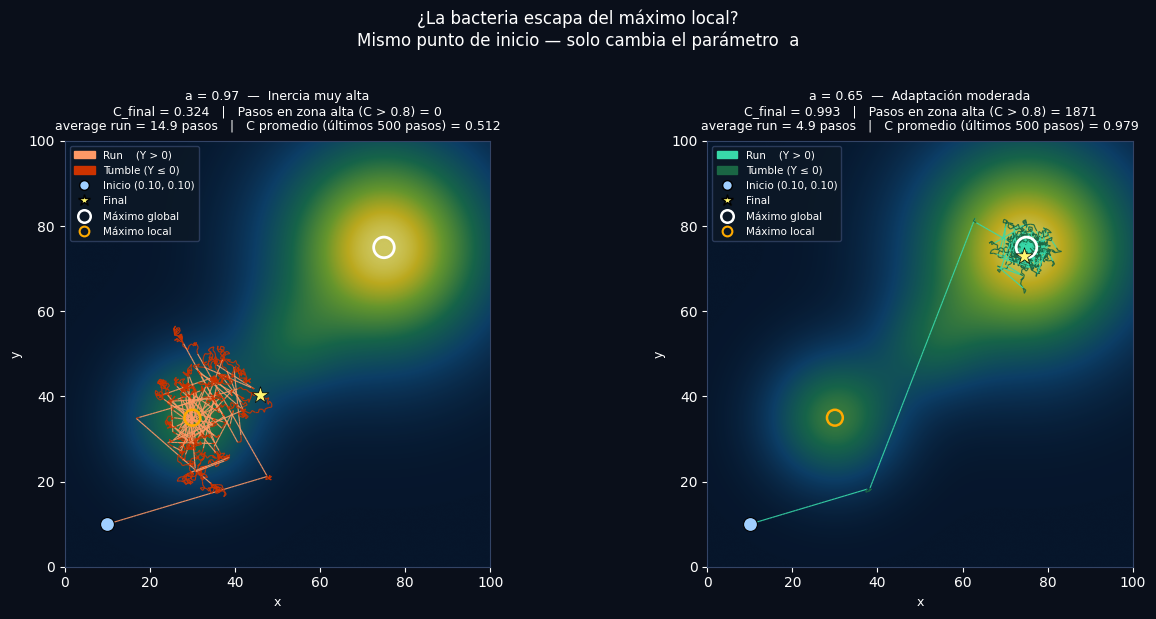

─────────────────────────────────────────────────────────────────
  TABLA COMPARATIVA
─────────────────────────────────────────────────────────────────
  Métrica                                   a=0.97       a=0.65
─────────────────────────────────────────────────────────────────
  Concentración final C(x_final, y_final)       0.3243       0.9931
  Pasos con C > 0.8 (zona máximo global)            0         1871
  C promedio — últimos 500 pasos            0.5115       0.9789
  Duración media de un run (pasos)            14.9          4.9
  % del tiempo en modo run                   49.2%        56.3%
─────────────────────────────────────────────────────────────────

╔══════════════════════════════════════════════════════════════════╗
║  PREGUNTAS                                                       ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. Observa la duración media de los runs en c

In [ ]:
#@title **Ejercicio — Máximos locales y adaptación sensorial**

# ═══════════════════════════════════════════════════════════════════════════════
# EJERCICIO — ¿Puede la bacteria escapar del máximo local?
# Requiere: landscape_original (Cell 1) y SalmonellaAgent (Cell 3)

# OBJETIVO
# ────────
# Comparar dos valores de 'a' con el mismo punto de inicio.
# Observar cómo la inercia sensorial determina si la bacteria
# queda atrapada en zonas de baja concentración o alcanza el máximo global.

# PREGUNTA GUÍA
# ─────────────
# ¿Por qué una adaptación sensorial moderada (a=0.65) permite escapar,
# mientras que una inercia muy alta (a=0.97) atrapa al agente?
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# ══════════════════════════════════════════════════════════════════════════════
# 1. CONFIGURACIONES A COMPARAR
# ══════════════════════════════════════════════════════════════════════════════

#  Config 1 — Inercia muy alta (a=0.97)
#    Y decae solo un 3% por paso → runs muy largos (avg ≈15 pasos)
#    El agente sobrepasa los picos antes de poder reorientarse

#  Config 2 — Balance moderado (a=0.65)
#    Y decae un 35% por paso → runs cortos y reactivos (avg ≈5 pasos)
#    El agente actualiza su dirección con frecuencia, siguiendo el gradiente
#    Resultado: llega al máximo global en pocos pasos y permanece ahí (ajusta constantemente)

CONFIGS = [
    dict(
        a=0.97, b=5.0, sigma_noise=0.00,
        label="a = 0.97  —  Inercia muy alta",
        color_run="#ff9966",    # naranja
        color_tumb="#cc3300",   # rojo oscuro
    ),
    dict(
        a=0.65, b=5.0, sigma_noise=0.00,
        label="a = 0.65  —  Adaptación moderada",
        color_run="#38d9a9",    # verde-cyan
        color_tumb="#1a6644",   # verde oscuro
    ),
]

N_STEPS = 2000
X0, Y0  = 0.10, 0.10   # mismo punto de inicio para ambas configuraciones
SEED    = 41           # semilla fija → resultados reproducibles y contrastados

# ══════════════════════════════════════════════════════════════════════════════
# 2. SIMULACIÓN
# ══════════════════════════════════════════════════════════════════════════════

agents = []
for cfg in CONFIGS:
    np.random.seed(SEED)
    ag = SalmonellaAgent(
        landscape_original,
        dict(a=cfg["a"], b=cfg["b"], sigma_noise=cfg["sigma_noise"],
             speed=0.008, x0=X0, y0=Y0, Y0=0.0)
    )
    ag.run_simulation(N_STEPS)
    agents.append(ag)

# ══════════════════════════════════════════════════════════════════════════════
# 3. MÉTRICAS DIAGNÓSTICAS
# ══════════════════════════════════════════════════════════════════════════════

# Zona de alta concentración: C > 0.80 (rango del máximo global)
UMBRAL_ALTO = 0.80

def _metrics(ag):
    hx    = np.array(ag.history_x)
    hy    = np.array(ag.history_y)
    hX    = np.array(ag.history_X)
    modes = ag.history_mode
    n_run = modes.count("run")

    # Pasos con C > umbral (zona del máximo global)
    pasos_alto = int(np.sum(hX > UMBRAL_ALTO))

    # Run-length promedio
    rls=[]; cur=0
    for m in modes:
        if m=="run": cur+=1
        else:
            if cur>0: rls.append(cur); cur=0
    if cur>0: rls.append(cur)
    avg_rl = np.mean(rls) if rls else 0

    # Concentración promedio últimos 500 pasos (régimen estacionario)
    c_estac = float(np.mean(hX[-500:]))

    c_fin = landscape_original.get_concentration(ag.x, ag.y)
    return dict(
        c_fin      = c_fin,
        pasos_alto = pasos_alto,
        avg_rl     = avg_rl,
        c_estac    = c_estac,
        pct_run    = 100 * n_run / len(modes),
    )

metricas = [_metrics(ag) for ag in agents]

# ══════════════════════════════════════════════════════════════════════════════
# 4. VISUALIZACIÓN
# ══════════════════════════════════════════════════════════════════════════════

BG       = "#0a0f1a"
COL_META = "#fff570"
COL_TRAP = "#ffaa00"
COL_INI  = "#a0cfff"

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor(BG)
fig.suptitle(
    "¿La bacteria escapa del máximo local?\n"
    "Mismo punto de inicio — solo cambia el parámetro  a",
    color="white", fontsize=12, y=1.02
)

for ax, ag, cfg, m in zip(axes, agents, CONFIGS, metricas):
    ax.set_facecolor(BG)

    # ── Fondo: paisaje ────────────────────────────────────────────────────────
    ax.imshow(
        landscape_original.grid, origin="lower",
        cmap=landscape_original.cmap,
        extent=[0, 100, 0, 100], aspect="equal",
        vmin=0, vmax=1, alpha=0.80
    )

    # ── Trayectoria coloreada por modo ────────────────────────────────────────
    hx = np.array(ag.history_x) * 100
    hy = np.array(ag.history_y) * 100
    is_run = np.array(ag.history_mode) == "run"

    points = np.array([hx, hy]).T.reshape(-1, 1, 2)
    segs   = np.concatenate([points[:-1], points[1:]], axis=1)
    cols   = [cfg["color_run"] if is_run[i] else cfg["color_tumb"]
              for i in range(len(segs))]
    ax.add_collection(LineCollection(segs, colors=cols,
                                     linewidths=0.85, alpha=0.90, zorder=3))

    # ── Anillos de referencia ─────────────────────────────────────────────────
    # Máximo global
    ax.scatter(PEAKS[0]["cx"]*100, PEAKS[0]["cy"]*100,
               s=220, facecolors="none", edgecolors="#ffffff",
               linewidths=2, zorder=5)
    # Máximo local (trampa)
    ax.scatter(PEAKS[1]["cx"]*100, PEAKS[1]["cy"]*100,
               s=130, facecolors="none", edgecolors=COL_TRAP,
               linewidths=1.8, zorder=5)

    # ── Marcadores inicio / final ─────────────────────────────────────────────
    ax.scatter(hx[0],  hy[0],  s=100, color=COL_INI,  edgecolors="#000",
               linewidths=0.8, zorder=7, marker="o")
    ax.scatter(hx[-1], hy[-1], s=160, color=COL_META, edgecolors="#000",
               linewidths=0.5, zorder=7, marker="*")

    # ── Título con métricas ───────────────────────────────────────────────────
    ax.set_title(
        f"{cfg['label']}\n"
        f"C_final = {m['c_fin']:.3f}   |   "
        f"Pasos en zona alta (C > {UMBRAL_ALTO}) = {m['pasos_alto']}\n"
        f"average run = {m['avg_rl']:.1f} pasos   |   "
        f"C promedio (últimos 500 pasos) = {m['c_estac']:.3f}",
        color="white", fontsize=9, pad=8
    )

    # ── Leyenda ───────────────────────────────────────────────────────────────
    ax.legend(
        handles=[
            mpatches.Patch(color=cfg["color_run"],  label="Run    (Y > 0)"),
            mpatches.Patch(color=cfg["color_tumb"], label="Tumble (Y ≤ 0)"),
            plt.Line2D([0],[0], marker="o", color="none",
                       markerfacecolor=COL_INI, markersize=7,
                       label=f"Inicio ({X0:.2f}, {Y0:.2f})"),
            plt.Line2D([0],[0], marker="*", color="none",
                       markerfacecolor=COL_META, markersize=9, label="Final"),
            plt.Line2D([0],[0], marker="o", color="none",
                       markerfacecolor="none", markeredgecolor="#ffffff",
                       markersize=9, markeredgewidth=1.8, label="Máximo global"),
            plt.Line2D([0],[0], marker="o", color="none",
                       markerfacecolor="none", markeredgecolor=COL_TRAP,
                       markersize=7, markeredgewidth=1.5, label="Máximo local"),
        ],
        fontsize=7.5, facecolor="#0d1825", edgecolor="#334466",
        labelcolor="white", loc="upper left"
    )

    ax.set_xlabel("x", color="white", fontsize=9)
    ax.set_ylabel("y", color="white", fontsize=9)
    ax.tick_params(colors="white")
    for sp in ax.spines.values():
        sp.set_edgecolor("#334466")

plt.tight_layout(rect=[0, 0.0, 1, 1])
plt.savefig("ejercicio_maximos_locales.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 5. TABLA COMPARATIVA
# ══════════════════════════════════════════════════════════════════════════════

print("─" * 65)
print("  TABLA COMPARATIVA")
print("─" * 65)
print(f"  {'Métrica':<35} {'a=0.97':>12} {'a=0.65':>12}")
print("─" * 65)
rows = [
    ("Concentración final C(x_final, y_final)",
     f"{metricas[0]['c_fin']:.4f}", f"{metricas[1]['c_fin']:.4f}"),
    (f"Pasos con C > {UMBRAL_ALTO} (zona máximo global)",
     f"{metricas[0]['pasos_alto']}", f"{metricas[1]['pasos_alto']}"),
    ("C promedio — últimos 500 pasos",
     f"{metricas[0]['c_estac']:.4f}", f"{metricas[1]['c_estac']:.4f}"),
    ("Duración media de un run (pasos)",
     f"{metricas[0]['avg_rl']:.1f}", f"{metricas[1]['avg_rl']:.1f}"),
    ("% del tiempo en modo run",
     f"{metricas[0]['pct_run']:.1f}%", f"{metricas[1]['pct_run']:.1f}%"),
]
for label, v1, v2 in rows:
    print(f"  {label:<35} {v1:>12} {v2:>12}")
print("─" * 65)

# ══════════════════════════════════════════════════════════════════════════════
# 6. PREGUNTAS DEL EJERCICIO
# ══════════════════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════╗
║  PREGUNTAS                                                       ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. Observa la duración media de los runs en cada configuración. ║
║     ¿Por qué runs más cortos permiten seguir el gradiente mejor? ║
║                                                                  ║
║  2. ¿Qué mecanismo hace que la inercia alta saque al agente      ║
║     de la trampa pero lo lleve a zonas aun peores?               ║
║                                                                  ║
║  3. ¿Con cuál valor de a la bacteria escapa del máximo local     ║
║     y por qué?                                                   ║
║                                                                  ║
║  4. ¿Por qué la adaptación sensorial es necesaria para escapar?  ║
╚══════════════════════════════════════════════════════════════════╝

NOTA: Para esta celda se utilizó semilla 42 (dirección de inicio del agente).
""")

Ejecutando simulaciones...
Listo.



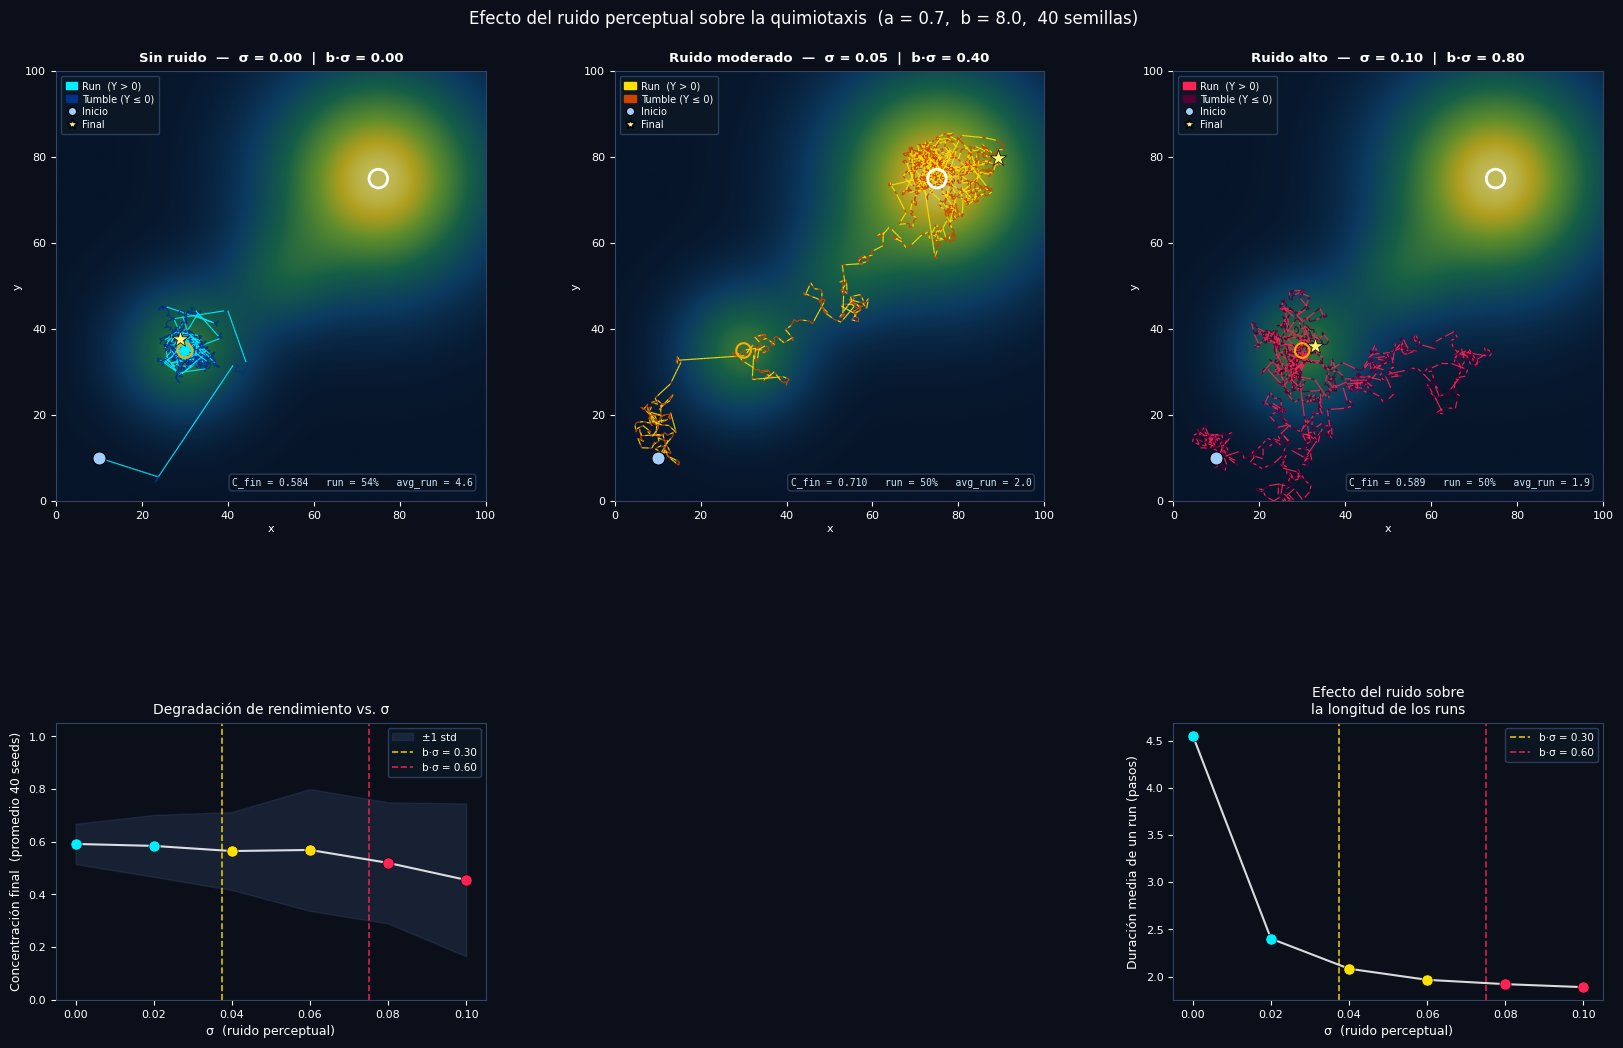

In [ ]:
#@title **Comportamiento del agente bajo ruido**

# ═══════════════════════════════════════════════════════════════════════════════
# EJERCICIO — ¿Cómo afecta el ruido perceptual a la quimiotaxis?
# Requiere: landscape_original (Cell 1) y SalmonellaAgent (Cell 3)

# NARRATIVA
# ─────────
# En quimiotaxis real, la bacteria no mide C(x,y) con precisión perfecta.
# Las fluctuaciones térmicas, el número finito de receptores y la difusión
# introducen ruido en cada medición:

#   X_medido = C(x,y) + ε,    ε ~ N(0, σ²)
#
# El estado interno del agente amplifica esa señal ruidosa con ganancia b:
#
#   Y(t+1) = a·Y(t) + b·[X_medido(t+1) − X_medido(t)]
#           = a·Y(t) + b·ΔC_real  +  b·Δε
#              ↑ señal               ↑ ruido amplificado
#
# El indicador clave es  b·σ:
#   • b·σ << |ΔC_real|  → señal domina → comportamiento quimiotáctico
#   • b·σ >> |ΔC_real|  → ruido domina → caminata casi aleatoria
#
# RESULTADO TEÓRICO IMPORTANTE (verificado numéricamente):
#   Con umbral fijo en Y=0, cambiar b escala señal y ruido por igual.
#   El signo de Y(t) — y por tanto la proporción run/tumble —
#   es INDEPENDIENTE de b. Solo σ y a determinan la robustez.
#
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec

# ══════════════════════════════════════════════════════════════════════════════
# 1. PARÁMETROS DEL EJERCICIO
# ══════════════════════════════════════════════════════════════════════════════

A_FIXED  = 0.70
B_FIXED  = 8.0
N_STEPS  = 2000
N_SEEDS  = 40
X0, Y0   = 0.10, 0.10

# ── Paleta — alto contraste run/tumble por caso ────────────────────────────────
#   run  = tono vivo y brillante
#   tumble = versión oscura y complementaria (máximo contraste perceptual)
CASOS_VISUAL = [
    dict(sigma=0.00, label="Sin ruido",      sub="σ = 0.00  |  b·σ = 0.00",
         col_run="#00eeff", col_tumb="#003388"),   # cian brillante / azul marino
    dict(sigma=0.05, label="Ruido moderado", sub="σ = 0.05  |  b·σ = 0.40",
         col_run="#ffe000", col_tumb="#cc4400"),   # amarillo puro / naranja quemado
    dict(sigma=0.10, label="Ruido alto",     sub="σ = 0.10  |  b·σ = 0.80",
         col_run="#ff2255", col_tumb="#550033"),   # rojo vivo / granate oscuro
]

SIGMAS_STAT = [0.00, 0.02, 0.04, 0.06, 0.08, 0.10]

# ══════════════════════════════════════════════════════════════════════════════
# 2. SIMULACIONES
# ══════════════════════════════════════════════════════════════════════════════

print("Ejecutando simulaciones...")

# Trayectorias visuales (seed=42)
agentes_visual = []
for cfg in CASOS_VISUAL:
    np.random.seed(42)
    ag = SalmonellaAgent(
        landscape_original,
        dict(a=A_FIXED, b=B_FIXED, sigma_noise=cfg["sigma"],
             speed=0.008, x0=X0, y0=Y0, Y0=0.0)
    )
    ag.run_simulation(N_STEPS)
    agentes_visual.append(ag)

# Estadísticas multi-seed
stat = {}
for sigma in SIGMAS_STAT:
    cfins = []; avg_rls = []
    for seed in range(N_SEEDS):
        np.random.seed(seed)
        ag = SalmonellaAgent(
            landscape_original,
            dict(a=A_FIXED, b=B_FIXED, sigma_noise=sigma,
                 speed=0.008, x0=X0, y0=Y0, Y0=0.0)
        )
        ag.run_simulation(N_STEPS)
        cfins.append(landscape_original.get_concentration(ag.x, ag.y))
        modes = ag.history_mode
        rls=[]; cur=0
        for m in modes:
            if m=="run": cur+=1
            else:
                if cur>0: rls.append(cur); cur=0
        if cur>0: rls.append(cur)
        avg_rls.append(np.mean(rls) if rls else 0)
    stat[sigma] = dict(
        c_mean    = np.mean(cfins),
        c_std     = np.std(cfins),
        frac_alta = sum(c > 0.80 for c in cfins) / N_SEEDS,
        avg_rl    = np.mean(avg_rls),
        bs        = B_FIXED * sigma,
    )

print("Listo.\n")

# ══════════════════════════════════════════════════════════════════════════════
# 3. FIGURA
# ══════════════════════════════════════════════════════════════════════════════

BG       = "#0a0f1a"
COL_META = "#fff570"
COL_TRAP = "#ffaa00"
COL_INI  = "#a0cfff"

# Colores estadísticos consistentes con la paleta de casos
STAT_COLORS = {
    "low":  "#00eeff",   # b·σ < 0.30
    "mid":  "#ffe000",   # 0.30 ≤ b·σ < 0.60
    "high": "#ff2255",   # b·σ ≥ 0.60
}

def _stat_color(bs):
    return STAT_COLORS["low"] if bs < 0.30 else (
           STAT_COLORS["mid"] if bs < 0.60 else STAT_COLORS["high"])

fig = plt.figure(figsize=(17, 11))
fig.patch.set_facecolor(BG)

# Fila superior más alta (trayectorias) que la inferior (gráficas)
gs = GridSpec(
    2, 3, figure=fig,
    height_ratios=[1.6, 1.0],
    hspace=0.60,
    wspace=0.30,
    top=0.92, bottom=0.07,
    left=0.06, right=0.97
)

fig.suptitle(
    f"Efecto del ruido perceptual sobre la quimiotaxis  "
    f"(a = {A_FIXED},  b = {B_FIXED},  {N_SEEDS} semillas)",
    color="white", fontsize=12, y=0.97
)

def _style(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors="white", labelsize=8)
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for sp in ax.spines.values():
        sp.set_edgecolor("#334466")

# ══════════════════════════════════════════════════════════════════════════════
# FILA SUPERIOR — 3 trayectorias
# ══════════════════════════════════════════════════════════════════════════════

for col_idx, (cfg, ag) in enumerate(zip(CASOS_VISUAL, agentes_visual)):
    ax = fig.add_subplot(gs[0, col_idx])
    _style(ax)

    # Paisaje
    ax.imshow(landscape_original.grid, origin="lower",
              cmap=landscape_original.cmap,
              extent=[0,100,0,100], aspect="equal",
              vmin=0, vmax=1, alpha=0.75)

    # Trayectoria
    hx = np.array(ag.history_x) * 100
    hy = np.array(ag.history_y) * 100
    is_run = np.array(ag.history_mode) == "run"

    points = np.array([hx, hy]).T.reshape(-1,1,2)
    segs   = np.concatenate([points[:-1], points[1:]], axis=1)
    col_segs = [cfg["col_run"] if is_run[i] else cfg["col_tumb"]
                for i in range(len(segs))]
    ax.add_collection(LineCollection(segs, colors=col_segs,
                                     linewidths=0.85, alpha=0.92, zorder=3))

    # Marcadores
    ax.scatter(hx[0], hy[0], s=90, color=COL_INI,
               edgecolors="#000", linewidths=0.8, zorder=7, marker="o")
    ax.scatter(hx[-1], hy[-1], s=150, color=COL_META,
               edgecolors="#000", linewidths=0.5, zorder=7, marker="*")
    ax.scatter(PEAKS[0]["cx"]*100, PEAKS[0]["cy"]*100,
               s=180, facecolors="none", edgecolors="#ffffff", lw=2, zorder=5)
    ax.scatter(PEAKS[1]["cx"]*100, PEAKS[1]["cy"]*100,
               s=110, facecolors="none", edgecolors=COL_TRAP, lw=1.5, zorder=5)

    # Métricas del agente
    cfin  = landscape_original.get_concentration(ag.x, ag.y)
    modes = ag.history_mode
    n_run = modes.count("run")
    rls=[]; cur=0
    for m in modes:
        if m=="run": cur+=1
        else:
            if cur>0: rls.append(cur); cur=0
    avg_rl = np.mean(rls) if rls else 0

    # Título: solo label + sub, fuera del plot
    ax.set_title(
        f"{cfg['label']}  —  {cfg['sub']}",
        color="white", fontsize=9.5, pad=7, fontweight="bold"
    )

    # Métricas en caja translúcida, esquina inferior derecha del plot
    ax.text(
        97, 3,
        f"C_fin = {cfin:.3f}   run = {100*n_run/len(modes):.0f}%   avg_run = {avg_rl:.1f}",
        color="#cce8ff", fontsize=7, fontfamily="monospace",
        ha="right", va="bottom", zorder=9,
        bbox=dict(facecolor="#0a0f1a", edgecolor="#334466",
                  alpha=0.80, pad=3, boxstyle="round,pad=0.3")
    )

    ax.set_xlabel("x", fontsize=8, labelpad=2)
    ax.set_ylabel("y", fontsize=8, labelpad=2)

    # Leyenda en esquina superior derecha (no hay trayectoria en esa zona)
    ax.legend(
        handles=[
            mpatches.Patch(color=cfg["col_run"],  label="Run  (Y > 0)"),
            mpatches.Patch(color=cfg["col_tumb"], label="Tumble (Y ≤ 0)"),
            plt.Line2D([0],[0], marker="o", color="none",
                       markerfacecolor=COL_INI, markersize=6, label="Inicio"),
            plt.Line2D([0],[0], marker="*", color="none",
                       markerfacecolor=COL_META, markersize=8, label="Final"),
        ],
        fontsize=7, facecolor="#0d1825", edgecolor="#334466",
        labelcolor="white", loc="upper left",
        framealpha=0.85, borderpad=0.5, handlelength=1.2,
        handletextpad=0.5, labelspacing=0.3
    )

# ══════════════════════════════════════════════════════════════════════════════
# FILA INFERIOR — 2 gráficas estadísticas (cols 0 y 2, centradas bajo trayectorias)
# ══════════════════════════════════════════════════════════════════════════════

sigmas_arr = np.array(SIGMAS_STAT)
c_means    = np.array([stat[s]["c_mean"] for s in SIGMAS_STAT])
c_stds     = np.array([stat[s]["c_std"]  for s in SIGMAS_STAT])
avg_rls    = np.array([stat[s]["avg_rl"] for s in SIGMAS_STAT])
bs_arr     = np.array([stat[s]["bs"]     for s in SIGMAS_STAT])
colors_pts = [_stat_color(bs) for bs in bs_arr]

# ── Inferior izquierda: C_mean vs σ ───────────────────────────────────────────
ax_l = fig.add_subplot(gs[1, 0])
_style(ax_l)

ax_l.fill_between(sigmas_arr, c_means - c_stds, c_means + c_stds,
                  color="#334466", alpha=0.35, zorder=1, label="±1 std")
ax_l.plot(sigmas_arr, c_means, color="white", linewidth=1.5,
          zorder=3, alpha=0.85)
for s, cm, col in zip(sigmas_arr, c_means, colors_pts):
    ax_l.scatter(s, cm, color=col, s=65, zorder=4,
                 edgecolors="#000", linewidths=0.4)
ax_l.axvline(0.30/B_FIXED, color=STAT_COLORS["mid"], linewidth=1.2,
             linestyle="--", alpha=0.85, label="b·σ = 0.30")
ax_l.axvline(0.60/B_FIXED, color=STAT_COLORS["high"], linewidth=1.2,
             linestyle="--", alpha=0.85, label="b·σ = 0.60")

ax_l.set_xlabel("σ  (ruido perceptual)", fontsize=9)
ax_l.set_ylabel("Concentración final  (promedio 40 seeds)", fontsize=9)
ax_l.set_title("Degradación de rendimiento vs. σ", fontsize=10, pad=7)
ax_l.set_ylim(0, 1.05)
ax_l.legend(fontsize=7.5, facecolor="#0d1825", edgecolor="#334466",
            labelcolor="white", loc="upper right", framealpha=0.85)

# ── Inferior derecha: avg_run vs σ ────────────────────────────────────────────
ax_r = fig.add_subplot(gs[1, 2])
_style(ax_r)

ax_r.plot(sigmas_arr, avg_rls, color="white", linewidth=1.5,
          zorder=3, alpha=0.85)
for s, rl, col in zip(sigmas_arr, avg_rls, colors_pts):
    ax_r.scatter(s, rl, color=col, s=65, zorder=4,
                 edgecolors="#000", linewidths=0.4)
ax_r.axvline(0.30/B_FIXED, color=STAT_COLORS["mid"], linewidth=1.2,
             linestyle="--", alpha=0.85, label="b·σ = 0.30")
ax_r.axvline(0.60/B_FIXED, color=STAT_COLORS["high"], linewidth=1.2,
             linestyle="--", alpha=0.85, label="b·σ = 0.60")

ax_r.set_xlabel("σ  (ruido perceptual)", fontsize=9)
ax_r.set_ylabel("Duración media de un run (pasos)", fontsize=9)
ax_r.set_title("Efecto del ruido sobre\nla longitud de los runs",
               fontsize=10, pad=7)
ax_r.legend(fontsize=7.5, facecolor="#0d1825", edgecolor="#334466",
            labelcolor="white", loc="upper right", framealpha=0.85)

plt.savefig("ejercicio_ruido.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Créditos y licencia

Este notebook es parte del proyecto:

> **Bouzas, A. (2026).** *Aprendizaje y Comportamiento Adaptable: Principios y Modelos.*  
> Lab25, Facultad de Psicología, UNAM.  
> https://www.bouzaslab25.com
>
Apoyo en la construcción del simulador: Eduardo Sánchez.

Código disponible en: **https://github.com/bouzaslab25/libro-aca**  
Licencia: [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/)
